## Virtual Moving Test 2 (V2V) Plotting Results

In [1]:
import os, re
import json
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FormatStrFormatter

from datetime import datetime
import math
import pandas as pd
from itertools import chain

from utils import post_process_get_moving_test_data_and_timestamp
from utils import remove_outlier_by_quantile
from static_data_processing import get_test_files_and_survey
from plot_utils import *
from stats_utils import *

from pandas.core.common import SettingWithCopyWarning
import warnings
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

ROOT_DIR = os.path.join("C:/Users/wangz/OneDrive/University_RU/NSUWB/")
CALIBRATED_CAM_TO_V2B = -6400.8
pd.set_option('display.float_format', lambda x: '%.5f' % x)
pd.set_option('display.max_columns', None)

RESAMPLE_RULE = "1S"

static_main_master = 'D91E'
static_focusing_slaves = ['1912', '8D38']
static_master_slave_mapping = { 'D91E': [static_focusing_slaves[0], static_focusing_slaves[1]],
                                '0090': [static_focusing_slaves[1], static_focusing_slaves[0]]}
moving_main_master = '88BA'
moving_focusing_slaves = ['DB00', '069B']
moving_master_slave_mapping = { '88BA': [moving_focusing_slaves[0], moving_focusing_slaves[1]],
                                '111C': [moving_focusing_slaves[1], moving_focusing_slaves[0]]}
static_veh, moving_veh = 3, 2
all_test_files, ground_truth_list = post_process_get_moving_test_data_and_timestamp(ROOT_DIR, "Moving Test 2 (Virtual Vehicle)", "V2", CALIBRATED_CAM_TO_V2B)
assert(len(all_test_files) == len(ground_truth_list))
all_test_names_dup = [os.path.basename(os.path.dirname(f)) for f in all_test_files]
# Remove Duplicates of Test Names
all_test_names = []
_ = [all_test_names.append(x) for x in all_test_names_dup if x not in all_test_names]
test_raw_name_file_map = {}
for i in range(len(all_test_names)):
    test_raw_name_file_map[all_test_names[i]] = {}
    a_side_file, b_side_file = all_test_files[2*i], all_test_files[2*i+1]
    test_raw_name_file_map[all_test_names[i]]["A"] = a_side_file
    test_raw_name_file_map[all_test_names[i]]["B"] = b_side_file
    test_raw_name_file_map[all_test_names[i]]["ground_truth"] = ground_truth_list[2*i]
virtual_moving_tests = {}

In [2]:
def parse_single_test_data(test_file, ground_truth):
    # moving test and virtual test parser - identical
    _test_csv_base = "PostProcessed_" + os.path.splitext(os.path.basename(test_file))[0] + ".csv"
    _integ_csv_base = "Integrated_ABAB_COMBO-" + _test_csv_base.split("PostProcessed_")[1].split("-data-")[0] + ".csv"
    _integ_csv_dir = os.path.join(os.path.dirname(test_file), _integ_csv_base)

    # Processing Statistics
    base_folder = os.path.dirname(_integ_csv_dir)
    raw_name = os.path.basename(os.path.dirname(_integ_csv_dir))
    print("processing: " + raw_name)
    df = pd.read_csv(_integ_csv_dir, parse_dates=["Datetime Normalized"], index_col=["Datetime Normalized"])

    # Adding additional columns
    df["Test Name"] = raw_name
    df["Test Category"] = "Moving Test"
    df["Aggregated Update Rate (Hz)"] = np.nan
    df['UWB Measured Instant Speed - Strict Pair (mph)'] = np.nan
    df['Aggregated Measured Speed (mph)'] = np.nan
    df['Test Start Time'] = pd.to_datetime(re.match('^[0-9]+[\-][0-9]+[\-][0-9]+[\-][0-9]+[\-][0-9]+[\-][0-9]+', 
                                                    raw_name)[0],
                                           format="%Y-%m-%d-%H-%M-%S")
    # Filter out distance measurement outliers
    df, df_outlier = uwb_dist_outlier_identify(df, segments = 5)
    # Remove duplicated index
    _newindex = df.reset_index().groupby("Datetime Normalized")["Datetime Normalized"]\
                    .apply(lambda x: x + np.arange(x.size).astype('timedelta64[ms]'))
    df.index = _newindex
    if df.empty:
        print(raw_name + " No Data")
        return None

    # Separting data frames by data-receiving vehicles 
    moving_ground_truth_df = ground_truth
    if moving_ground_truth_df is not None:
        _ground_df = moving_ground_truth_df.copy()
        _ground_df = _ground_df.append({"DIST_GROUND_TRUTH_CPLR_TO_CPLR (mm)":0.0,
                                        "Time UNIX Norm (s)":np.nan,
                                        "Marker Name ":"n/a",
                                        "Camera Dist to Static Veh (CPLR, mm)":-CALIBRATED_CAM_TO_V2B,
                                        "Datetime Normalized":pd.NaT},
                                       ignore_index=True).set_index("DIST_GROUND_TRUTH_CPLR_TO_CPLR (mm)")
        _ground_df = _ground_df.sort_index().interpolate()
        _ground_df["Datetime Normalized"] = pd.to_datetime(_ground_df["Time UNIX Norm (s)"], unit='s')
        zero_time = _ground_df[_ground_df.index == 0.0]["Datetime Normalized"].min()
    else:
        zero_time = df.index.min()
    if not pd.isnull(zero_time):
        df_static_veh_all_pairs = df[(df['Initiating Vehicle'] == static_veh) & (df.index >= zero_time)]
        df_moving_veh_all_pairs = df[(df['Initiating Vehicle'] == moving_veh) & (df.index >= zero_time)]
    else:
        df_static_veh_all_pairs = df[df['Initiating Vehicle'] == static_veh]
        df_moving_veh_all_pairs = df[df['Initiating Vehicle'] == moving_veh]
    df_static_veh_all_pairs.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], ascending=[True, True], inplace=True)
    df_moving_veh_all_pairs.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], ascending=[True, True], inplace=True)

    # Adding update rate metrics: strict pairs and instant speed 
    df_static_veh_hz_aggregated_all_pairs = update_rate_by_strict_pairs(df_static_veh_all_pairs, 
                                                                        static_master_slave_mapping.keys(), 
                                                                        static_focusing_slaves)
    df_moving_veh_hz_aggregated_all_pairs = update_rate_by_strict_pairs(df_moving_veh_all_pairs, 
                                                                        moving_master_slave_mapping.keys(), 
                                                                        moving_focusing_slaves)
    df_static_veh_hz_aggregated_all_pairs = instant_spd_by_strict_pairs(df_static_veh_hz_aggregated_all_pairs, 
                                                                        static_master_slave_mapping.keys(), 
                                                                        static_focusing_slaves)
    df_moving_veh_hz_aggregated_all_pairs = instant_spd_by_strict_pairs(df_moving_veh_hz_aggregated_all_pairs, 
                                                                        moving_master_slave_mapping.keys(), 
                                                                        moving_focusing_slaves)
    df_static_veh_hz_aggregated_all_pairs.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], 
                                                      ascending=[True, True], inplace=True)
    df_moving_veh_hz_aggregated_all_pairs.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], 
                                                      ascending=[True, True], inplace=True)
    truth_static_veh_interpolated, truth_moving_veh_interpolated = None, None
    real_time_err_static_veh, real_time_err_moving_veh = None, None
    static_bins, moving_bins = None, None
    # Calculate Ground Truth Instant Speed
    if moving_ground_truth_df is not None:
        dist_diff = moving_ground_truth_df["Camera Dist to Static Veh (CPLR, mm)"].diff()
        time_diff = moving_ground_truth_df["Time UNIX Norm (s)"].diff()
        instant_spd = (dist_diff / time_diff) * 0.00223694
        moving_ground_truth_df["Instant Speed by Marker (mph)"] = instant_spd
        
        ground_truth_aligned = (moving_ground_truth_df.set_index("Datetime Normalized")
                    .dropna()
                    .rename(columns={"DIST_GROUND_TRUTH_CPLR_TO_CPLR (mm)": "Correction Distance (mm)"})[
                        ["Correction Distance (mm)"]])
        
        # Interpolated Ground Truth by Static/Moving Vehicle Measured Time Indices
        static_veh_idx_realigned = ground_truth_aligned.append(
            ground_truth_aligned.reindex_like(
                df_static_veh_hz_aggregated_all_pairs[["Correction Distance (mm)"]])).sort_index()
        truth_static_veh_interpolated = static_veh_idx_realigned[
            (static_veh_idx_realigned.index >= static_veh_idx_realigned.first_valid_index()) & 
            (static_veh_idx_realigned.index <= static_veh_idx_realigned.last_valid_index())].interpolate()
        truth_static_veh_interpolated = truth_static_veh_interpolated[
            ~truth_static_veh_interpolated.index.isin(ground_truth_aligned.index)
            ]
        moving_veh_idx_realigned = ground_truth_aligned.append(
            ground_truth_aligned.reindex_like(
                df_moving_veh_hz_aggregated_all_pairs[["Correction Distance (mm)"]])).sort_index()
        truth_moving_veh_interpolated = moving_veh_idx_realigned[
            (moving_veh_idx_realigned.index >= moving_veh_idx_realigned.first_valid_index()) & 
            (moving_veh_idx_realigned.index <= moving_veh_idx_realigned.last_valid_index())].interpolate()
        truth_moving_veh_interpolated = truth_moving_veh_interpolated[
            ~truth_moving_veh_interpolated.index.isin(ground_truth_aligned.index)
            ]
        
        # Range for interpolated measurement errors
        real_time_err_static_veh = (df_static_veh_hz_aggregated_all_pairs[["Correction Distance (mm)"]] 
                                    - truth_static_veh_interpolated).rename(columns={"Correction Distance (mm)":"Error (mm)"})
        real_time_err_moving_veh = (df_moving_veh_hz_aggregated_all_pairs[["Correction Distance (mm)"]] 
                                    - truth_moving_veh_interpolated).rename(columns={"Correction Distance (mm)":"Error (mm)"})
        
        binwidth = 20
        _raw_uwb_err_static = real_time_err_static_veh["Error (mm)"].dropna()
        _raw_uwb_err_moving = real_time_err_moving_veh["Error (mm)"].dropna()
        static_hist_disp_range = (_raw_uwb_err_static.quantile(0.05), _raw_uwb_err_static.quantile(0.95))
        static_hist_disp_range = None if np.nan in static_hist_disp_range else static_hist_disp_range
        static_bins = np.arange(min(_raw_uwb_err_static), 
                                max(_raw_uwb_err_static) + binwidth, 
                                binwidth) if not _raw_uwb_err_static.empty else None
        moving_hist_disp_range = (_raw_uwb_err_moving.quantile(0.05), _raw_uwb_err_moving.quantile(0.95))
        moving_hist_disp_range = None if np.nan in moving_hist_disp_range else moving_hist_disp_range
        moving_bins = np.arange(min(_raw_uwb_err_moving), 
                                max(_raw_uwb_err_moving) + binwidth, 
                                binwidth) if not _raw_uwb_err_moving.empty else None
    
    return {"df_static_veh_hz_aggregated_all_pairs":df_static_veh_hz_aggregated_all_pairs, 
            "df_moving_veh_hz_aggregated_all_pairs":df_moving_veh_hz_aggregated_all_pairs, 
            "df_outlier":df_outlier,
            "df_static_veh_all_pairs":df_static_veh_all_pairs,
            "df_moving_veh_all_pairs":df_moving_veh_all_pairs,
            "static_veh":static_veh,
            "moving_veh":moving_veh,
            "moving_ground_truth_df":moving_ground_truth_df,
            "real_time_err_static_veh":real_time_err_static_veh,
            "real_time_err_moving_veh":real_time_err_moving_veh,
            "static_bins":static_bins,
            "moving_bins":moving_bins
            }

In [3]:
def plot_single_test_data(raw_name):
    parsing_results = virtual_moving_tests.get(raw_name)
    if not parsing_results:
        print(raw_name + " No Data, Not Plotting")
        return
    # Unpack dataframes
    df_static_veh_hz_aggregated_all_pairs = parsing_results["df_static_veh_hz_aggregated_all_pairs"]
    df_moving_veh_hz_aggregated_all_pairs = parsing_results["df_moving_veh_hz_aggregated_all_pairs"]
    df_outlier = parsing_results["df_outlier"]
    static_veh = parsing_results["static_veh"]
    moving_veh = parsing_results["moving_veh"]
    df_static_veh_all_pairs = parsing_results["df_static_veh_all_pairs"]
    df_moving_veh_all_pairs = parsing_results["df_moving_veh_all_pairs"]
    moving_ground_truth_df = parsing_results["moving_ground_truth_df"]
    static_bins = parsing_results["static_bins"]
    moving_bins = parsing_results["moving_bins"]
    real_time_err_static_veh = parsing_results["real_time_err_static_veh"]
    real_time_err_moving_veh = parsing_results["real_time_err_moving_veh"]
    ######################################################
    # Plotting individual tests
    ######################################################
    print("plotting: " + raw_name)
    figure = plt.figure(figsize=(16, 9), dpi=150)
    if "moving" in raw_name.split("-v2-")[0]:
        titlename = "Moving Test - " + raw_name.split("-v2-")[-1]
        figure.suptitle(titlename, fontsize='x-large', fontweight='bold')
    else:
        titlename = "Virtual Moving Test - " + raw_name.split("-v2-")[-1]
        figure.suptitle(titlename, fontsize='x-large', fontweight='bold')
    
    ######################################################
    ########## Original Results ##########
    ######################################################
    
    plot_time_series_dist(figure=figure,
                          arrange_spec=411,
                          static_veh_df=df_static_veh_hz_aggregated_all_pairs,
                          moving_veh_df=df_moving_veh_hz_aggregated_all_pairs,
                          static_veh=static_veh,
                          moving_veh=moving_veh,
                          df_outlier=df_outlier,
                          surveyed_static_ground_truth_value=None,
                          moving_ground_truth_df=moving_ground_truth_df,
                          scatter=True)

    plot_upd_rate(figure=figure,
                  arrange_spec=412,
                  static_veh_df=df_static_veh_hz_aggregated_all_pairs,
                  moving_veh_df=df_moving_veh_hz_aggregated_all_pairs,
                  static_veh=static_veh,
                  moving_veh=moving_veh,
                  moving_ground_truth_df=moving_ground_truth_df,
                  scatter=True)

    # Instant Speed UWB Strict
    # Calculate UWB Measured Instant Speed by Vehicle's Master with Each Slave to Range
    plot_time_series_speed(figure=figure, 
                           arrange_spec=413, 
                           static_veh_df=df_static_veh_hz_aggregated_all_pairs, 
                           moving_veh_df=df_moving_veh_hz_aggregated_all_pairs,
                           static_veh=static_veh,
                           moving_veh=moving_veh,
                           moving_ground_truth_df=moving_ground_truth_df,
                           scatter=True)
    
    plot_real_time_moving_errors(figure=figure, 
                                 arrange_spec=414, 
                                 static_veh_df=df_static_veh_hz_aggregated_all_pairs, 
                                 moving_veh_df=df_moving_veh_hz_aggregated_all_pairs,
                                 static_veh=static_veh,
                                 moving_veh=moving_veh,
                                 moving_ground_truth_df=moving_ground_truth_df,
                                 scatter=True)
    
    ######################################################
    ########## Error Histogram ##########
    ######################################################
    
    titlename = "Histogram of Real-Time Measurement Errors (Interpolated)"
    figure_hist = plt.figure(figsize=(16, 9), dpi=150)
    figure_hist.suptitle(titlename, fontsize='x-large', fontweight='bold')
    plot_hist_moving_err_hbar(figure=figure_hist,
                         static_veh=static_veh,
                         moving_veh=moving_veh,
                         real_time_err_static_veh=real_time_err_static_veh,
                         real_time_err_moving_veh=real_time_err_moving_veh,
                         bin_size_static=static_bins,
                         bin_size_moving=moving_bins
                         )
    
    ######################################################
    ########## RESAMPLED RESULTS ##########
    ######################################################
    figure_resample = plt.figure(figsize=(16, 9), dpi=150)
    titlename = titlename + "-Resampled"
    figure_resample.suptitle(titlename, fontsize='x-large', fontweight='bold')
    plot_time_series_dist(figure=figure_resample,
                          arrange_spec=411,
                          static_veh_df=df_static_veh_hz_aggregated_all_pairs,
                          moving_veh_df=df_moving_veh_hz_aggregated_all_pairs,
                          static_veh=static_veh,
                          moving_veh=moving_veh,
                          df_outlier=df_outlier,
                          surveyed_static_ground_truth_value=None,
                          moving_ground_truth_df=moving_ground_truth_df,
                          resample=True,
                          scatter=False)

    plot_upd_rate(figure=figure_resample,
                  arrange_spec=412,
                  static_veh_df=df_static_veh_hz_aggregated_all_pairs,
                  moving_veh_df=df_moving_veh_hz_aggregated_all_pairs,
                  static_veh=static_veh,
                  moving_veh=moving_veh,
                  moving_ground_truth_df=moving_ground_truth_df,
                  resample=True,
                  scatter=False)

    # Instant Speed UWB Strict
    # Calculate UWB Measured Instant Speed by Vehicle's Master with Each Slave to Range
    plot_time_series_speed(figure=figure_resample, 
                           arrange_spec=413, 
                           static_veh_df=df_static_veh_hz_aggregated_all_pairs, 
                           moving_veh_df=df_moving_veh_hz_aggregated_all_pairs,
                           static_veh=static_veh,
                           moving_veh=moving_veh,
                           moving_ground_truth_df=moving_ground_truth_df,
                           resample=True,
                           scatter=False)
    
    figure.tight_layout(pad=1.0)
    figure_hist.tight_layout(pad=1.0)
    figure_resample.tight_layout(pad=1.0)
    plt.show()
    

## Parse and store the data for all the tests

In [4]:
virtual_moving_tests = {}
for test in all_test_names:
    virtual_moving_tests[test] = parse_single_test_data(test_raw_name_file_map[test]["B"],
                                                        test_raw_name_file_map[test]["ground_truth"])

processing: 2021-05-25-13-00-19-v2-1-west
processing: 2021-05-25-13-01-56-v2-1-east
2021-05-25-13-01-56-v2-1-east No Data
processing: 2021-05-25-13-07-12-v2-2-west-10mph
processing: 2021-05-25-13-09-08-v2-2-east-15mph
2021-05-25-13-09-08-v2-2-east-15mph No Data
processing: 2021-05-25-13-10-51-v2-3-west-10mph
2021-05-25-13-10-51-v2-3-west-10mph No Data
processing: 2021-05-25-13-12-45-v2-3-east-10mph
2021-05-25-13-12-45-v2-3-east-10mph No Data
processing: 2021-05-25-13-14-27-v2-4-west-20mph
processing: 2021-05-25-13-16-54-v2-4-east-20mph
2021-05-25-13-16-54-v2-4-east-20mph No Data
processing: 2021-05-25-13-24-09-v2-5-west-10mph
processing: 2021-05-25-13-27-19-v2-5-east-15mph
2021-05-25-13-27-19-v2-5-east-15mph No Data
processing: 2021-05-25-13-30-54-v2-6-west-15mph
2021-05-25-13-30-54-v2-6-west-15mph No Data
processing: 2021-05-25-13-33-14-v2-6-east-25mph
2021-05-25-13-33-14-v2-6-east-25mph No Data
processing: 2021-05-25-13-39-32-v2-7-west-edgepush
processing: 2021-05-25-13-42-27-v2-edge

In [5]:
# Global Statistics
static_stats_list_pairwise = []
static_stats_list_aggregated = []
moving_stats_list_pairwise = []
moving_stats_list_aggregated = []

# Combination of All, Indexed by Ground Truth Distances
static_stats_dist_idx = []
moving_stats_dist_idx = []

# Combination of All, Indexed by Time
static_stats_time_idx = []
moving_stats_time_idx = []

for raw_name in all_test_names:
    parsing_results = virtual_moving_tests.get(raw_name)
    if not parsing_results:
        continue
    # Unpack dataframes
    df_static_veh_hz_aggregated_all_pairs = parsing_results["df_static_veh_hz_aggregated_all_pairs"]
    df_moving_veh_hz_aggregated_all_pairs = parsing_results["df_moving_veh_hz_aggregated_all_pairs"]
    df_outlier = parsing_results["df_outlier"]
    static_veh = parsing_results["static_veh"]
    moving_veh = parsing_results["moving_veh"]
    df_static_veh_all_pairs = parsing_results["df_static_veh_all_pairs"]
    df_moving_veh_all_pairs = parsing_results["df_moving_veh_all_pairs"]
    moving_ground_truth_df = parsing_results["moving_ground_truth_df"]
    
    df_static_veh_hz_aggregated_all_pairs = update_rate_by_strict_pairs(df_static_veh_all_pairs, 
                                                                        static_master_slave_mapping.keys(), 
                                                                        static_focusing_slaves)
    df_moving_veh_hz_aggregated_all_pairs = update_rate_by_strict_pairs(df_moving_veh_all_pairs, 
                                                                        moving_master_slave_mapping.keys(), 
                                                                        moving_focusing_slaves)
    df_static_veh_hz_aggregated_all_pairs = instant_spd_by_strict_pairs(df_static_veh_hz_aggregated_all_pairs, 
                                                                        static_master_slave_mapping.keys(), 
                                                                        static_focusing_slaves)
    df_moving_veh_hz_aggregated_all_pairs = instant_spd_by_strict_pairs(df_moving_veh_hz_aggregated_all_pairs, 
                                                                        moving_master_slave_mapping.keys(), 
                                                                        moving_focusing_slaves)

    df_static_veh_hz_aggregated_all_pairs.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], 
                                                      ascending=[True, True], 
                                                      inplace=True)
    df_moving_veh_hz_aggregated_all_pairs.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], 
                                                      ascending=[True, True], 
                                                      inplace=True)
    
    if moving_ground_truth_df is not None:
        # Calculate Ground Truth Instant Speed
        dist_diff = moving_ground_truth_df["Camera Dist to Static Veh (CPLR, mm)"].diff()
        time_diff = moving_ground_truth_df["Time UNIX Norm (s)"].diff()
        instant_spd = (dist_diff / time_diff) * 0.00223694
        moving_ground_truth_df["Instant Speed by Marker (mph)"] = instant_spd

        df_static_veh_hz_aggregated_all_pairs = interpolate_ground_truth(df_static_veh_hz_aggregated_all_pairs, 
                                                                         moving_ground_truth_df)
        df_moving_veh_hz_aggregated_all_pairs = interpolate_ground_truth(df_moving_veh_hz_aggregated_all_pairs, 
                                                                         moving_ground_truth_df)
    else:
        df_static_veh_hz_aggregated_all_pairs["Surveyed Distance (mm)"] = np.nan
        df_moving_veh_hz_aggregated_all_pairs["Surveyed Distance (mm)"] = np.nan
        df_static_veh_hz_aggregated_all_pairs["Instant Speed by Marker (mph)"] = np.nan
        df_moving_veh_hz_aggregated_all_pairs["Instant Speed by Marker (mph)"] = np.nan
    
    static_stats_time_idx.append(df_static_veh_hz_aggregated_all_pairs)
    moving_stats_time_idx.append(df_moving_veh_hz_aggregated_all_pairs)

    static_stats_dist_idx.append(df_static_veh_hz_aggregated_all_pairs.set_index("Surveyed Distance (mm)"))
    moving_stats_dist_idx.append(df_moving_veh_hz_aggregated_all_pairs.set_index("Surveyed Distance (mm)"))

    # Stats generate
    df_stats_pairwise_static = generate_stats_pairwise(df_static_veh_hz_aggregated_all_pairs, 
                                                       static_veh, 
                                                       None, 
                                                       static_master_slave_mapping, 
                                                       static_main_master,
                                                       raw_name)
    df_stats_aggregated_static = generate_stats_aggregated(df_static_veh_hz_aggregated_all_pairs, 
                                                           static_veh, 
                                                           None,
                                                           raw_name)
    static_stats_list_pairwise.append(df_stats_pairwise_static)
    static_stats_list_aggregated.append(df_stats_aggregated_static)
    df_stats_pairwise_moving = generate_stats_pairwise(df_moving_veh_hz_aggregated_all_pairs, 
                                                       moving_veh, 
                                                       None, 
                                                       moving_master_slave_mapping, 
                                                       moving_main_master,
                                                       raw_name)
    df_stats_aggregated_moving = generate_stats_aggregated(df_moving_veh_hz_aggregated_all_pairs, 
                                                           moving_veh, 
                                                           None,
                                                           raw_name)
    moving_stats_list_pairwise.append(df_stats_pairwise_moving)
    moving_stats_list_aggregated.append(df_stats_aggregated_moving)
    
df_all_static_stats_pairwise_moving_test = pd.concat(static_stats_list_pairwise, ignore_index=True)
df_all_static_stats_aggregated_moving_test = pd.concat(static_stats_list_aggregated, ignore_index=True)
df_all_static_stats_aggregated_moving_test["Main Pair Counts"] = np.array(
    df_all_static_stats_pairwise_moving_test[(df_all_static_stats_pairwise_moving_test["Is Main Master"]==True) & 
                                             (df_all_static_stats_pairwise_moving_test["Is Main Slave"]==True)
                                            ]["Reporting Counts"])
df_all_moving_stats_pairwise_moving_test = pd.concat(moving_stats_list_pairwise, ignore_index=True)
df_all_moving_stats_aggregated_moving_test = pd.concat(moving_stats_list_aggregated, ignore_index=True)
df_all_moving_stats_aggregated_moving_test["Main Pair Counts"] = np.array(
    df_all_moving_stats_pairwise_moving_test[(df_all_moving_stats_pairwise_moving_test["Is Main Master"]==True) & 
                                             (df_all_moving_stats_pairwise_moving_test["Is Main Slave"]==True)
                                            ]["Reporting Counts"])

df_all_static_stats_dist_idx_moving_test = pd.concat(static_stats_dist_idx)
df_all_static_stats_time_idx_moving_test = pd.concat(static_stats_time_idx)
df_all_moving_stats_dist_idx_moving_test = pd.concat(moving_stats_dist_idx)
df_all_moving_stats_time_idx_moving_test = pd.concat(moving_stats_time_idx)

## Virtual Moving Test 2 Overall Stats, Downtime

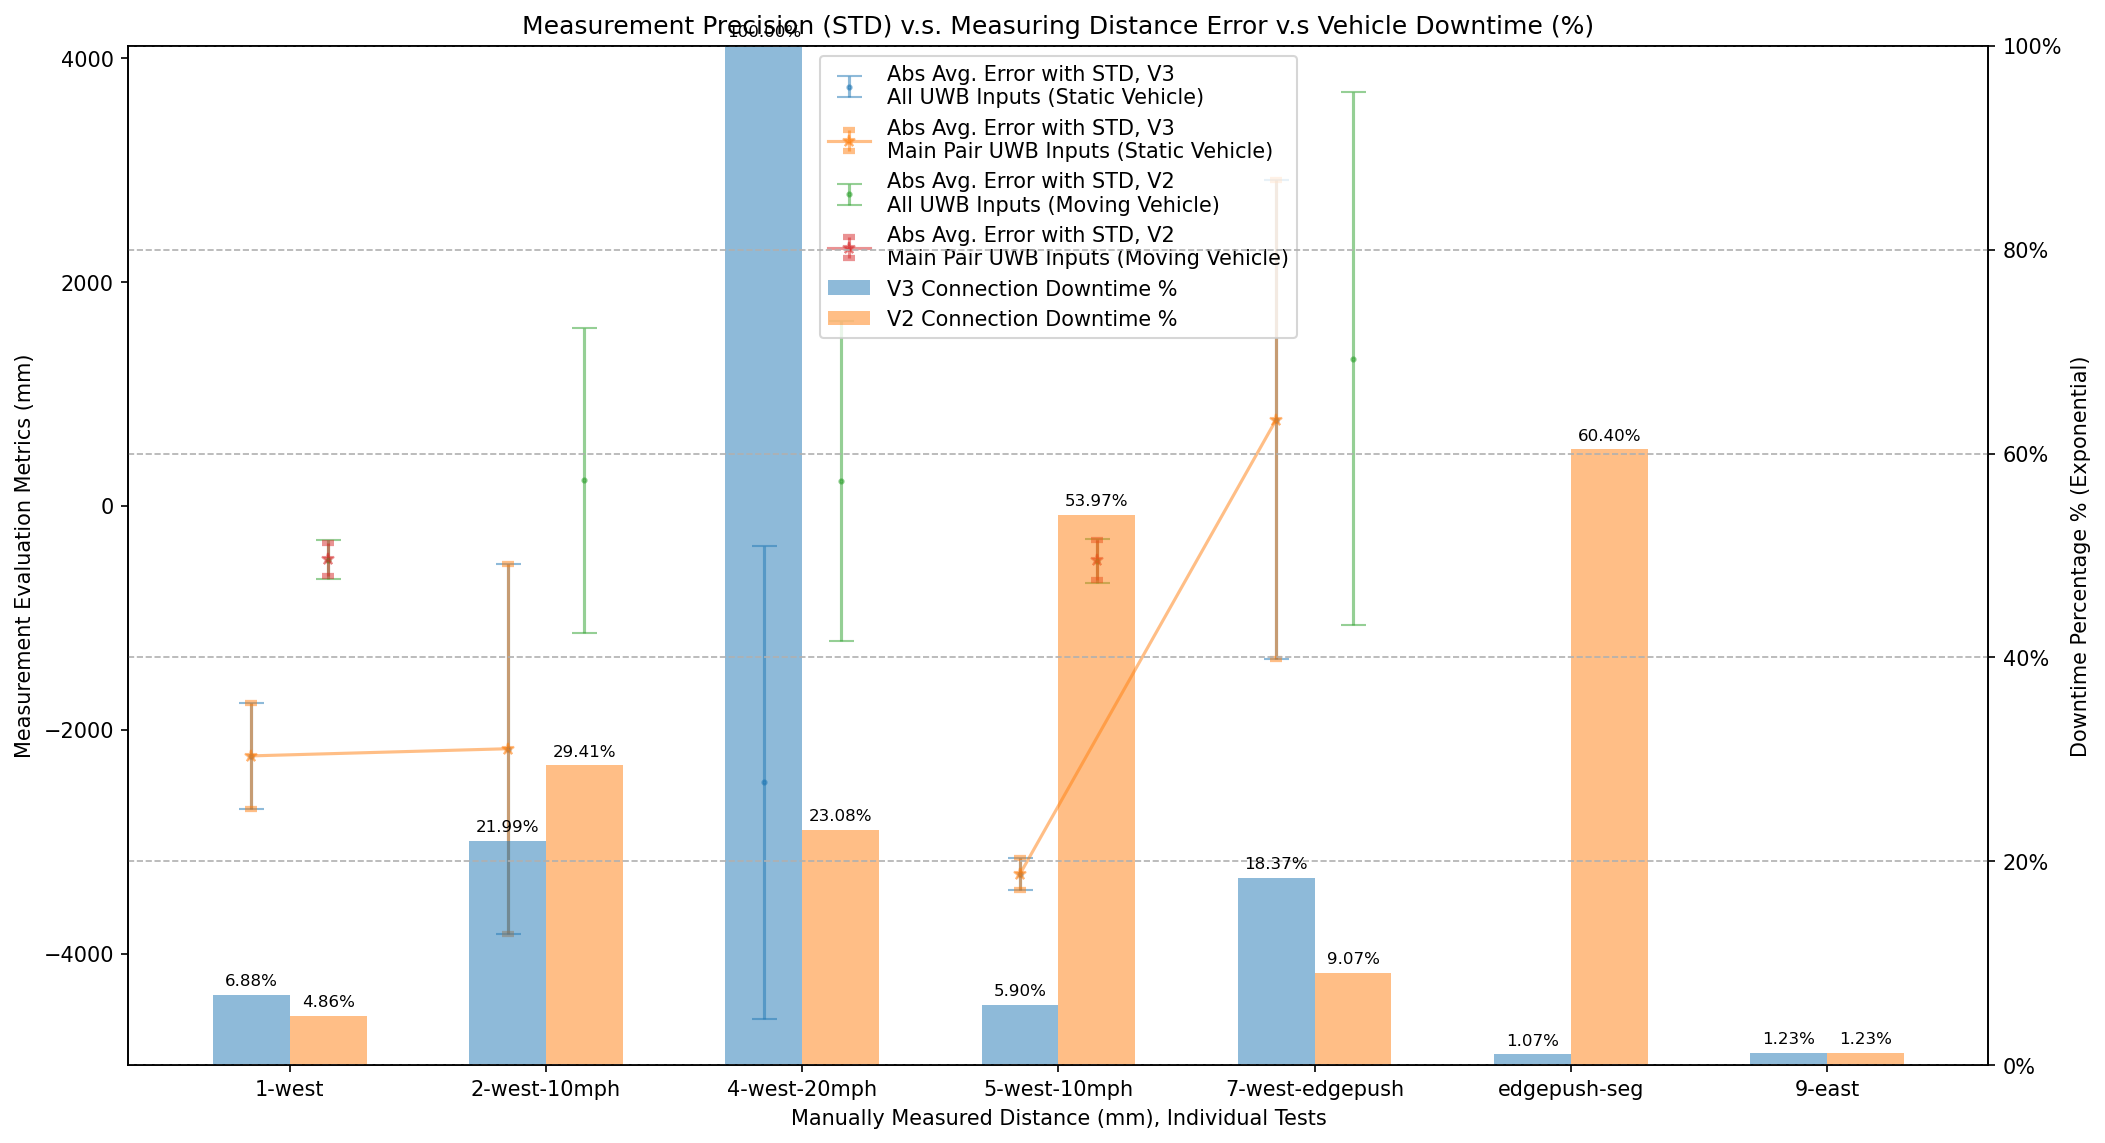

In [6]:
from matplotlib.ticker import FuncFormatter
figure = plt.figure(figsize=(16, 9), dpi=150)
width=0.3
labels = df_all_static_stats_aggregated_moving_test["Test Name"].astype(str)
ax = figure.add_subplot(111)
ax.set_title("Measurement Precision (STD) v.s. Measuring Distance Error v.s Vehicle Downtime (%)")
df_main_pair_static_veh_stats_moving_test = df_all_static_stats_pairwise_moving_test[
    (df_all_static_stats_pairwise_moving_test["Is Main Master"]==True) & 
    (df_all_static_stats_pairwise_moving_test["Is Main Slave"]==True)]
df_main_pair_moving_veh_stats_moving_test = df_all_moving_stats_pairwise_moving_test[
    (df_all_moving_stats_pairwise_moving_test["Is Main Master"]==True) & 
    (df_all_moving_stats_pairwise_moving_test["Is Main Slave"]==True)]
errbar_1 = ax.errorbar(x=np.arange(len(labels.index)) - width/2,
                       y=df_all_static_stats_aggregated_moving_test["Average Measurement Error (mm)"],
                       yerr=df_all_static_stats_aggregated_moving_test["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Static Vehicle)'.format(static_veh))
errbar_1_1 = ax.errorbar(x=np.arange(len(labels.index)) - width/2,
                         y=df_main_pair_static_veh_stats_moving_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_static_veh_stats_moving_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Static Vehicle)'.format(static_veh))
errbar_2 = ax.errorbar(x=np.arange(len(labels.index)) + width/2,
                       y=df_all_moving_stats_aggregated_moving_test["Average Measurement Error (mm)"],
                       yerr=df_all_moving_stats_aggregated_moving_test["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Moving Vehicle)'.format(moving_veh))
errbar_2_1 = ax.errorbar(x=np.arange(len(labels.index)) + width/2,
                         y=df_main_pair_moving_veh_stats_moving_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_moving_veh_stats_moving_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Moving Vehicle)'.format(moving_veh))
ax.set_xlabel("Manually Measured Distance (mm), Individual Tests")
ax.set_xticks(np.arange(len(labels.index)))
ax.set_xticklabels([x.split("-v2-")[1] for x in list(labels)])
ax.set_ylabel("Measurement Evaluation Metrics (mm)")
ax2 = ax.twinx()
rects1 = ax2.bar(np.arange(len(labels.index)) - width/2,
                 df_all_static_stats_aggregated_moving_test["Downtime Duration"] / \
                 df_all_static_stats_aggregated_moving_test["Operation Duration"],
                 width=width, label='V{} Connection Downtime %'.format(static_veh), alpha=0.5)
rects2 = ax2.bar(np.arange(len(labels.index)) + width/2,
                 df_all_moving_stats_aggregated_moving_test["Downtime Duration"] / \
                 df_all_moving_stats_aggregated_moving_test["Operation Duration"],
                 width=width, label='V{} Connection Downtime %'.format(moving_veh), alpha=0.5)
ax2.set_xticks(np.arange(len(labels.index)))
ax2.set_xticklabels([x.split("-v2-")[1] for x in list(labels)])
ax2.set_ylabel("Downtime Percentage % (Exponential)")
ax2.set_ylim([0, 1])
ax2.bar_label(rects1, padding=3, labels=['{:.2%}'.format(x).lstrip('0') for x in rects1.datavalues], fontsize=8)
ax2.bar_label(rects2, padding=3, labels=['{:.2%}'.format(x).lstrip('0') for x in rects2.datavalues], fontsize=8)
ax2.grid(axis='y', linestyle='--')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

ax.legend([errbar_1, errbar_1_1, errbar_2, errbar_2_1, rects1, rects2], 
          [errbar_1.get_label(), errbar_1_1.get_label(), errbar_2.get_label(), errbar_2_1.get_label(),
          rects1.get_label(), 
          rects2.get_label()],
          loc="upper center")

plt.show()

## Virtual Moving Test 2 Overall Stats, Reporting Counts

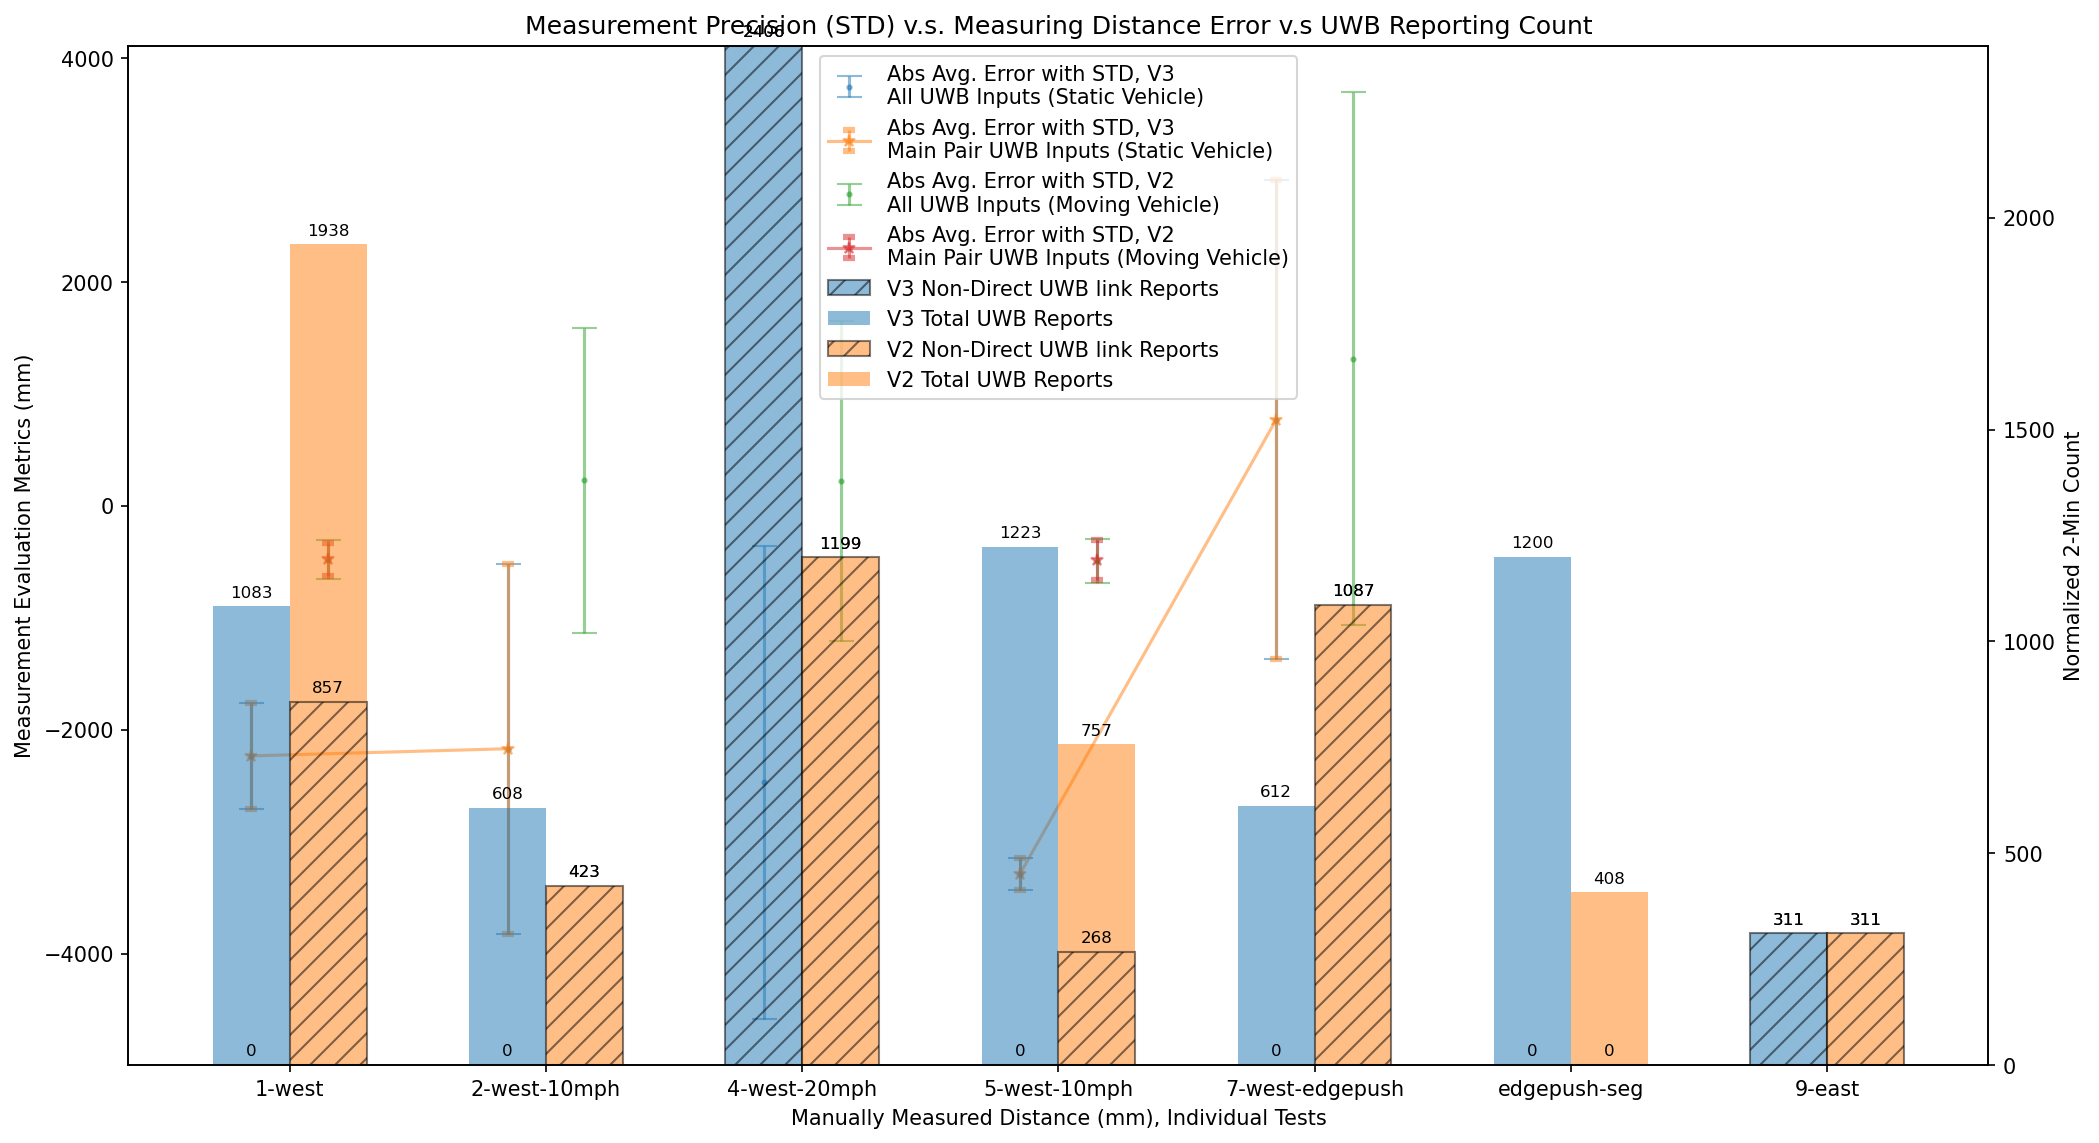

In [7]:
from matplotlib.ticker import FuncFormatter
figure = plt.figure(figsize=(16, 9), dpi=150)
width=0.3
labels = df_all_static_stats_aggregated_moving_test["Test Name"].astype(str)
ax = figure.add_subplot(111)
ax.set_title("Measurement Precision (STD) v.s. Measuring Distance Error v.s UWB Reporting Count")
df_main_pair_static_veh_stats_moving_test = df_all_static_stats_pairwise_moving_test[
    (df_all_static_stats_pairwise_moving_test["Is Main Master"]==True) & 
    (df_all_static_stats_pairwise_moving_test["Is Main Slave"]==True)]
df_main_pair_moving_veh_stats_moving_test = df_all_moving_stats_pairwise_moving_test[
    (df_all_moving_stats_pairwise_moving_test["Is Main Master"]==True) & 
    (df_all_moving_stats_pairwise_moving_test["Is Main Slave"]==True)]
errbar_1 = ax.errorbar(x=np.arange(len(labels.index)) - width/2,
                       y=df_all_static_stats_aggregated_moving_test["Average Measurement Error (mm)"],
                       yerr=df_all_static_stats_aggregated_moving_test["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Static Vehicle)'.format(static_veh))
errbar_1_1 = ax.errorbar(x=np.arange(len(labels.index)) - width/2,
                         y=df_main_pair_static_veh_stats_moving_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_static_veh_stats_moving_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Static Vehicle)'.format(static_veh))
errbar_2 = ax.errorbar(x=np.arange(len(labels.index)) + width/2,
                       y=df_all_moving_stats_aggregated_moving_test["Average Measurement Error (mm)"],
                       yerr=df_all_moving_stats_aggregated_moving_test["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Moving Vehicle)'.format(moving_veh))
errbar_2_1 = ax.errorbar(x=np.arange(len(labels.index)) + width/2,
                         y=df_main_pair_moving_veh_stats_moving_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_moving_veh_stats_moving_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Moving Vehicle)'.format(moving_veh))
ax.set_xlabel("Manually Measured Distance (mm), Individual Tests")
ax.set_xticks(np.arange(len(labels.index)))
ax.set_xticklabels([x.split("-v2-")[1] for x in list(labels)])
ax.set_ylabel("Measurement Evaluation Metrics (mm)")

ax2 = ax.twinx()

rects1 = ax2.bar(np.arange(len(labels.index)) - width/2,
                (df_all_static_stats_aggregated_moving_test["Main Pair Counts"] /
                 df_all_static_stats_aggregated_moving_test["Operation Duration"]*120).astype("int"), 
                 bottom=((df_all_static_stats_aggregated_moving_test["Reporting Counts"] - 
                         df_all_static_stats_aggregated_moving_test["Main Pair Counts"]) /
                        df_all_static_stats_aggregated_moving_test["Operation Duration"]*120).astype("int"),
                 width=width, 
                 label='V{} Total UWB Reports'.format(static_veh), alpha=0.5, color="C0")
rects0 = ax2.bar(np.arange(len(labels.index)) - width/2,
                ((df_all_static_stats_aggregated_moving_test["Reporting Counts"] - 
                  df_all_static_stats_aggregated_moving_test["Main Pair Counts"]) / 
                 df_all_static_stats_aggregated_moving_test["Operation Duration"]*120).astype("int"),
                 width=width, 
                 label='V{} Non-Direct UWB link Reports'.format(static_veh), 
                 alpha=0.5, color="C0", hatch="//", edgecolor='k')


rects3 = ax2.bar(np.arange(len(labels.index)) + width/2,
                (df_all_moving_stats_aggregated_moving_test["Main Pair Counts"] / 
                 df_all_moving_stats_aggregated_moving_test["Operation Duration"]*120).astype("int"), 
                 bottom=((df_all_moving_stats_aggregated_moving_test["Reporting Counts"] - 
                         df_all_moving_stats_aggregated_moving_test["Main Pair Counts"]) / 
                        df_all_moving_stats_aggregated_moving_test["Operation Duration"]*120).astype("int"),
                 width=width, 
                 label='V{} Total UWB Reports'.format(moving_veh), alpha=0.5, color="C1")
rects2 = ax2.bar(np.arange(len(labels.index)) + width/2,
                ((df_all_moving_stats_aggregated_moving_test["Reporting Counts"] - 
                  df_all_moving_stats_aggregated_moving_test["Main Pair Counts"]) / 
                 df_all_moving_stats_aggregated_moving_test["Operation Duration"]*120).astype("int"),
                 width=width, 
                 label='V{} Non-Direct UWB link Reports'.format(moving_veh), 
                 alpha=0.5, color="C1", hatch="//", edgecolor='k')

ax2.set_ylabel("Normalized 2-Min Count")
ax2.bar_label(rects1, padding=3, fontsize=8)
ax2.bar_label(rects0, padding=3, fontsize=8)
ax2.bar_label(rects3, padding=3, fontsize=8)
ax2.bar_label(rects2, padding=3, fontsize=8)
ax.legend([errbar_1, errbar_1_1, errbar_2, errbar_2_1, 
           rects0, rects1, rects2, rects3], 
          [errbar_1.get_label(), errbar_1_1.get_label(), errbar_2.get_label(), errbar_2_1.get_label(), 
           rects0.get_label(), rects1.get_label(), rects2.get_label(), rects3.get_label()],
          loc="upper center")
plt.show()

## Virtual Moving Test 2 Overall Stats, Error v.s. Distance

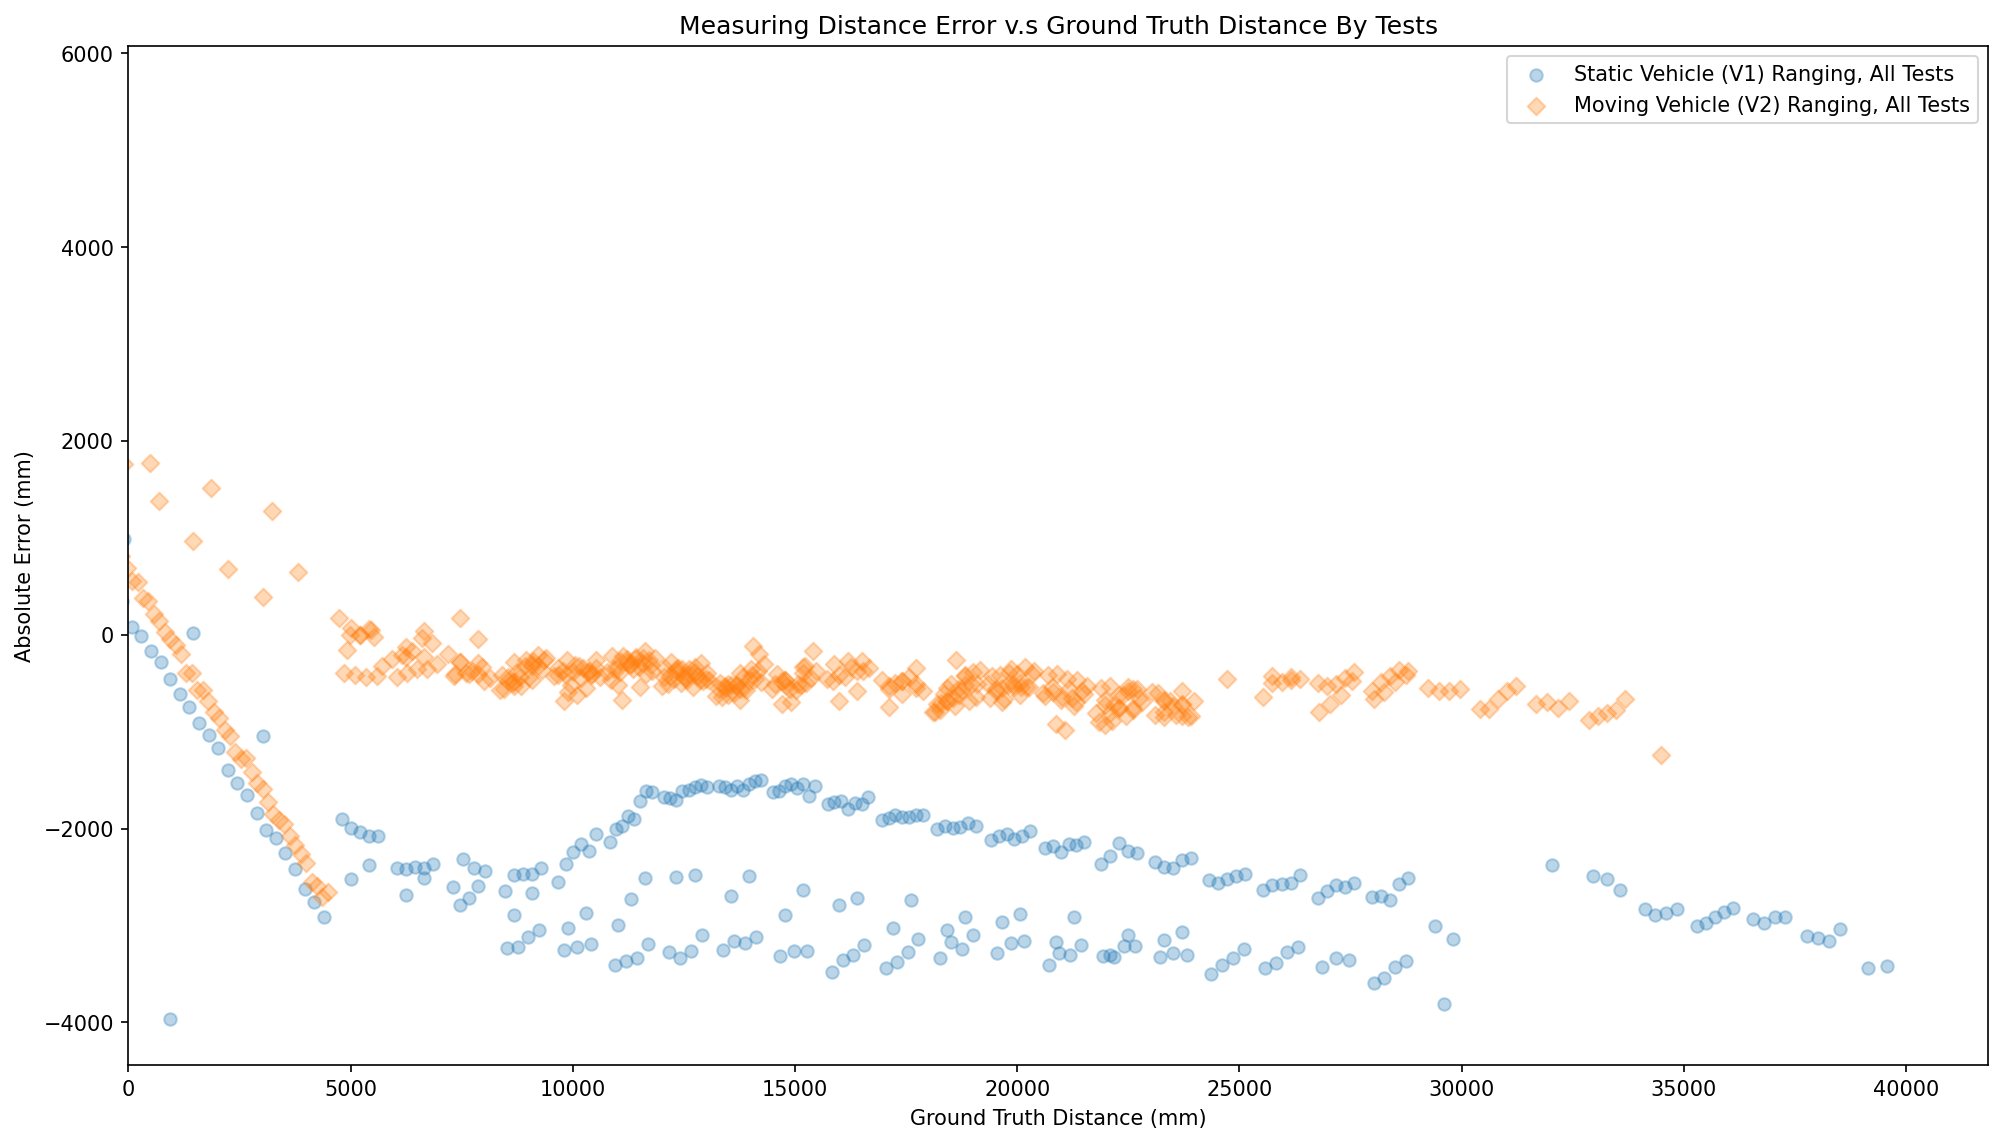

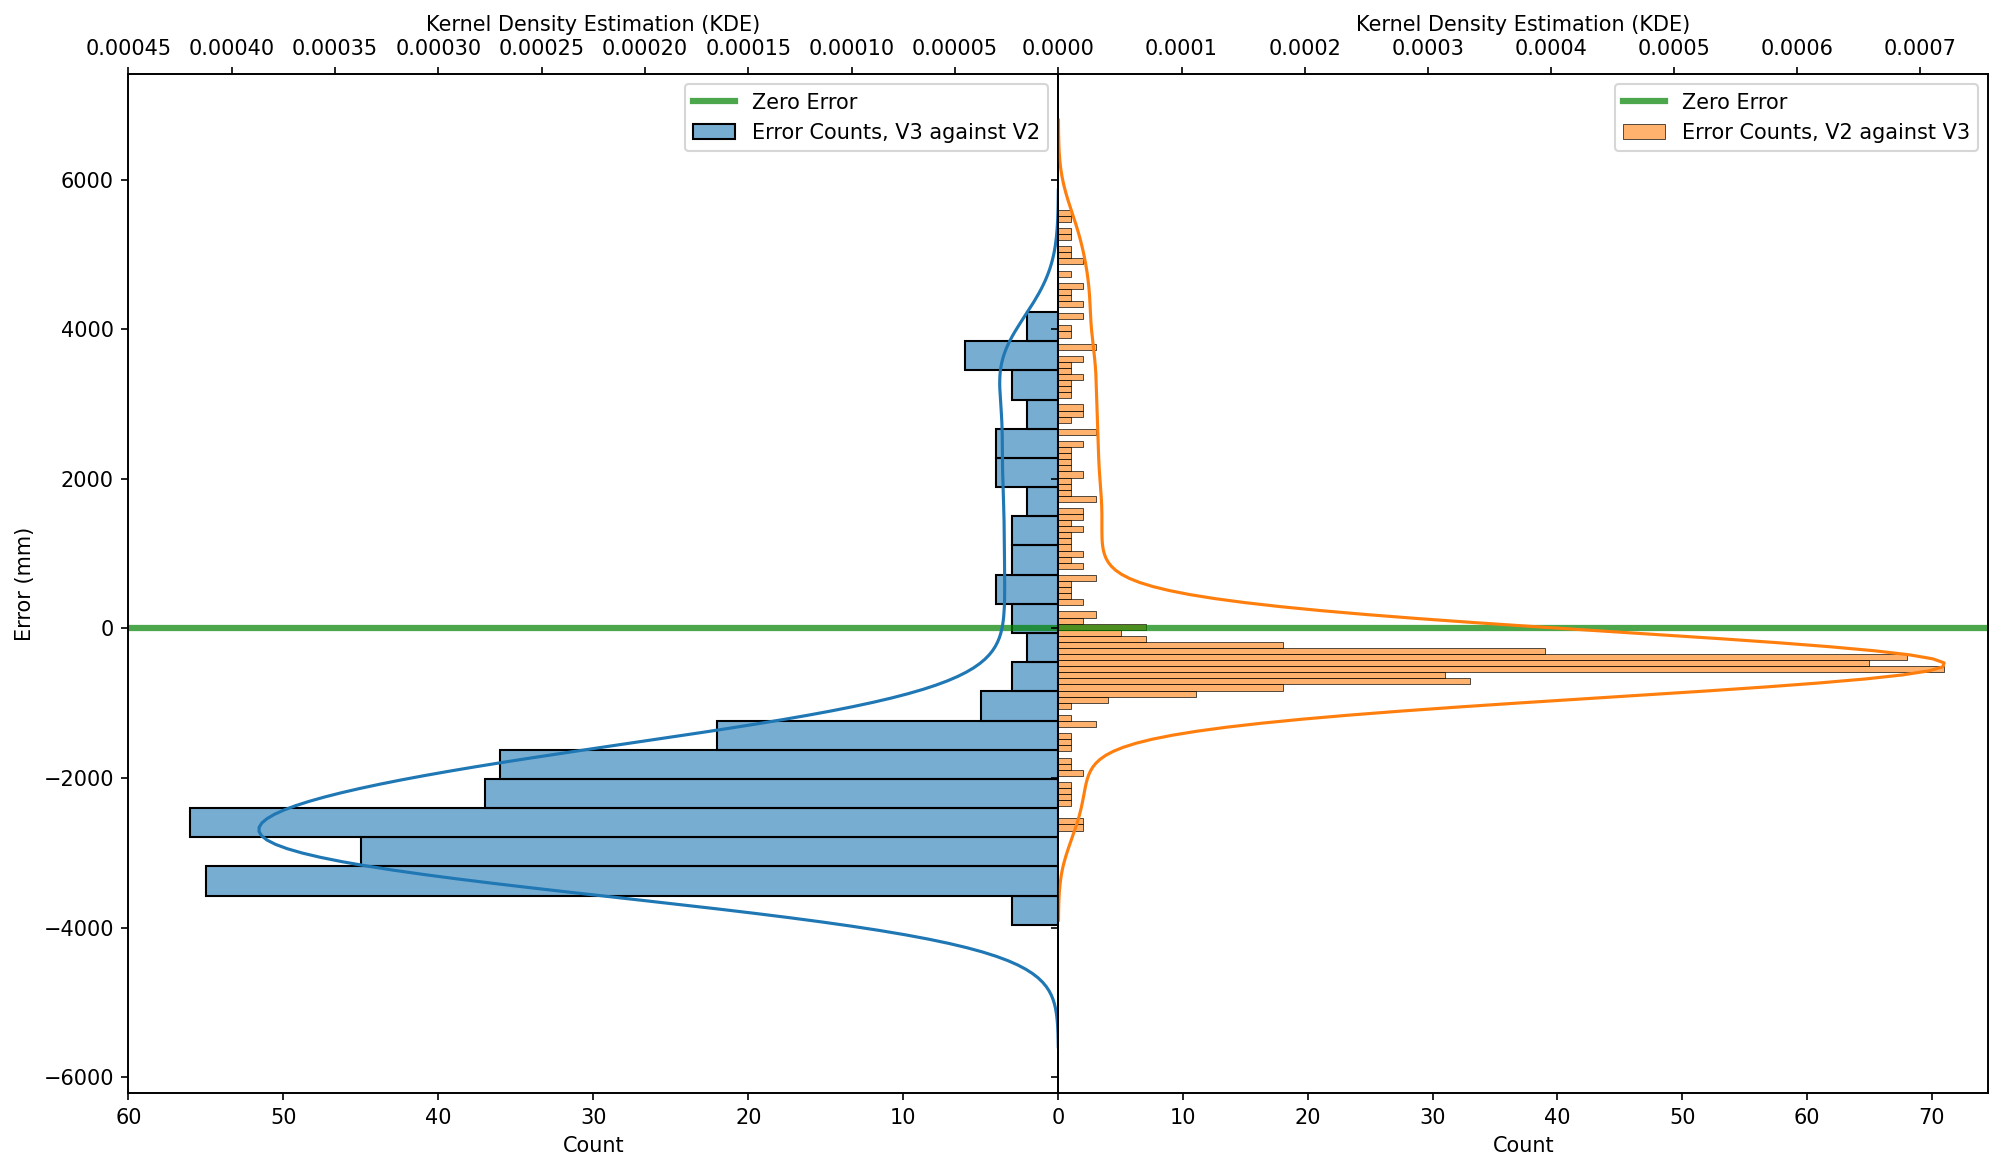

In [8]:
figure = plt.figure(figsize=(16, 9), dpi=150)
ax = figure.add_subplot(111)
ax.set_title("Measuring Distance Error v.s Ground Truth Distance By Tests")
labels = df_all_static_stats_dist_idx_moving_test["Test Name"].astype(str)
i = 0
for test in list(labels.unique()):
    _test_df_static = df_all_static_stats_dist_idx_moving_test[
        df_all_static_stats_dist_idx_moving_test["Test Name"] == test]
    _test_df_moving = df_all_moving_stats_dist_idx_moving_test[
        df_all_moving_stats_dist_idx_moving_test["Test Name"] == test]
    if i > 0:
        ax.scatter(_test_df_static.index, _test_df_static["Correction Distance (mm)"] - _test_df_static.index, 
                   alpha=0.3, marker="o", color="C0")
        ax.scatter(_test_df_moving.index, _test_df_moving["Correction Distance (mm)"] - _test_df_moving.index, 
                   alpha=0.3, marker="D", color="C1")
    else:
        ax.scatter(_test_df_static.index, _test_df_static["Correction Distance (mm)"] - _test_df_static.index, 
                   alpha=0.3, marker="o", color="C0", 
                   label = "Static Vehicle (V1) Ranging, All Tests")
        ax.scatter(_test_df_moving.index, _test_df_moving["Correction Distance (mm)"] - _test_df_moving.index, 
                   alpha=0.3, marker="D", color="C1", 
                   label = "Moving Vehicle (V2) Ranging, All Tests")
    i += 1
ax.set_xlabel("Ground Truth Distance (mm)")
ax.set_xlim(left=0)
ax.set_ylabel("Absolute Error (mm)")
ax.legend()

# Horizontal Histgram
figure = plt.figure(figsize=(16, 9), dpi=150)
axs = figure.subplots(1,2,sharey=True)
figure.subplots_adjust(wspace=0)
ax_static, ax_moving = axs[0], axs[1]
ax2_static, ax2_moving = axs[0].twiny(), axs[1].twiny()

my_palette = sns.color_palette("muted")

zero_static = ax_static.axhline(y=0, color="g", label="Zero Error", linewidth=3, alpha=0.7)
_data_static = ((df_all_static_stats_dist_idx_moving_test["Correction Distance (mm)"] 
                - df_all_static_stats_dist_idx_moving_test.index)
                .reset_index()
                .rename(columns={0 :'Error (mm)'}))
hist_static = sns.histplot(
    data=_data_static,
    y='Error (mm)',
    alpha =0.6,
    label="Error Counts, V{} against V{}".format(static_veh, moving_veh),
    ax=ax_static,
    color="C0"
)

kde_static = sns.kdeplot(
    data=_data_static,
    x='Error (mm)',
    ax=ax2_static,
    label="Kernel Density Distribution, V{} against V{}".format(static_veh, moving_veh), 
    linewidth=1.5,
    vertical=True,
    color="C0")

zero_moving = ax_moving.axhline(y=0, color="g", label="Zero Error", linewidth=3, alpha=0.7)
_data_moving = ((df_all_moving_stats_dist_idx_moving_test["Correction Distance (mm)"] 
                - df_all_moving_stats_dist_idx_moving_test.index)
                .reset_index()
                .rename(columns={0 :'Error (mm)'}))
hist_moving = sns.histplot(
    data=_data_moving,
    y='Error (mm)',
    alpha =0.6,
    label="Error Counts, V{} against V{}".format(moving_veh, static_veh),
    ax=ax_moving,
    color="C1"
)
kde_moving = sns.kdeplot(
    data=_data_moving,
    x='Error (mm)',
    ax=ax2_moving, 
    label="Kernel Density Distribution, V{} against V{}".format(moving_veh, static_veh), 
    linewidth=1.5,
    vertical=True, 
    color="C1")

ax_static.set_xlim(ax_static.get_xlim()[::-1])
ax2_static.set_xlim(ax2_static.get_xlim()[::-1])

ax2_static.set_xlabel("Kernel Density Estimation (KDE)")
ax2_moving.set_xlabel("Kernel Density Estimation (KDE)")

ax_static.set_xticks(ax_static.get_xticks()[1:])
ax2_static.set_xticks(ax2_static.get_xticks()[1:])

axs[0].legend()
axs[1].legend()
plt.show()

## Virtual Moving Test 2 Update Rate v.s. Locations, Scatter

### Static Vehicle

C:\Users\wangz\.conda\envs\py37iot\lib\site-packages\ipykernel_launcher.py:64: UserWarning: FixedFormatter should only be used together with FixedLocator


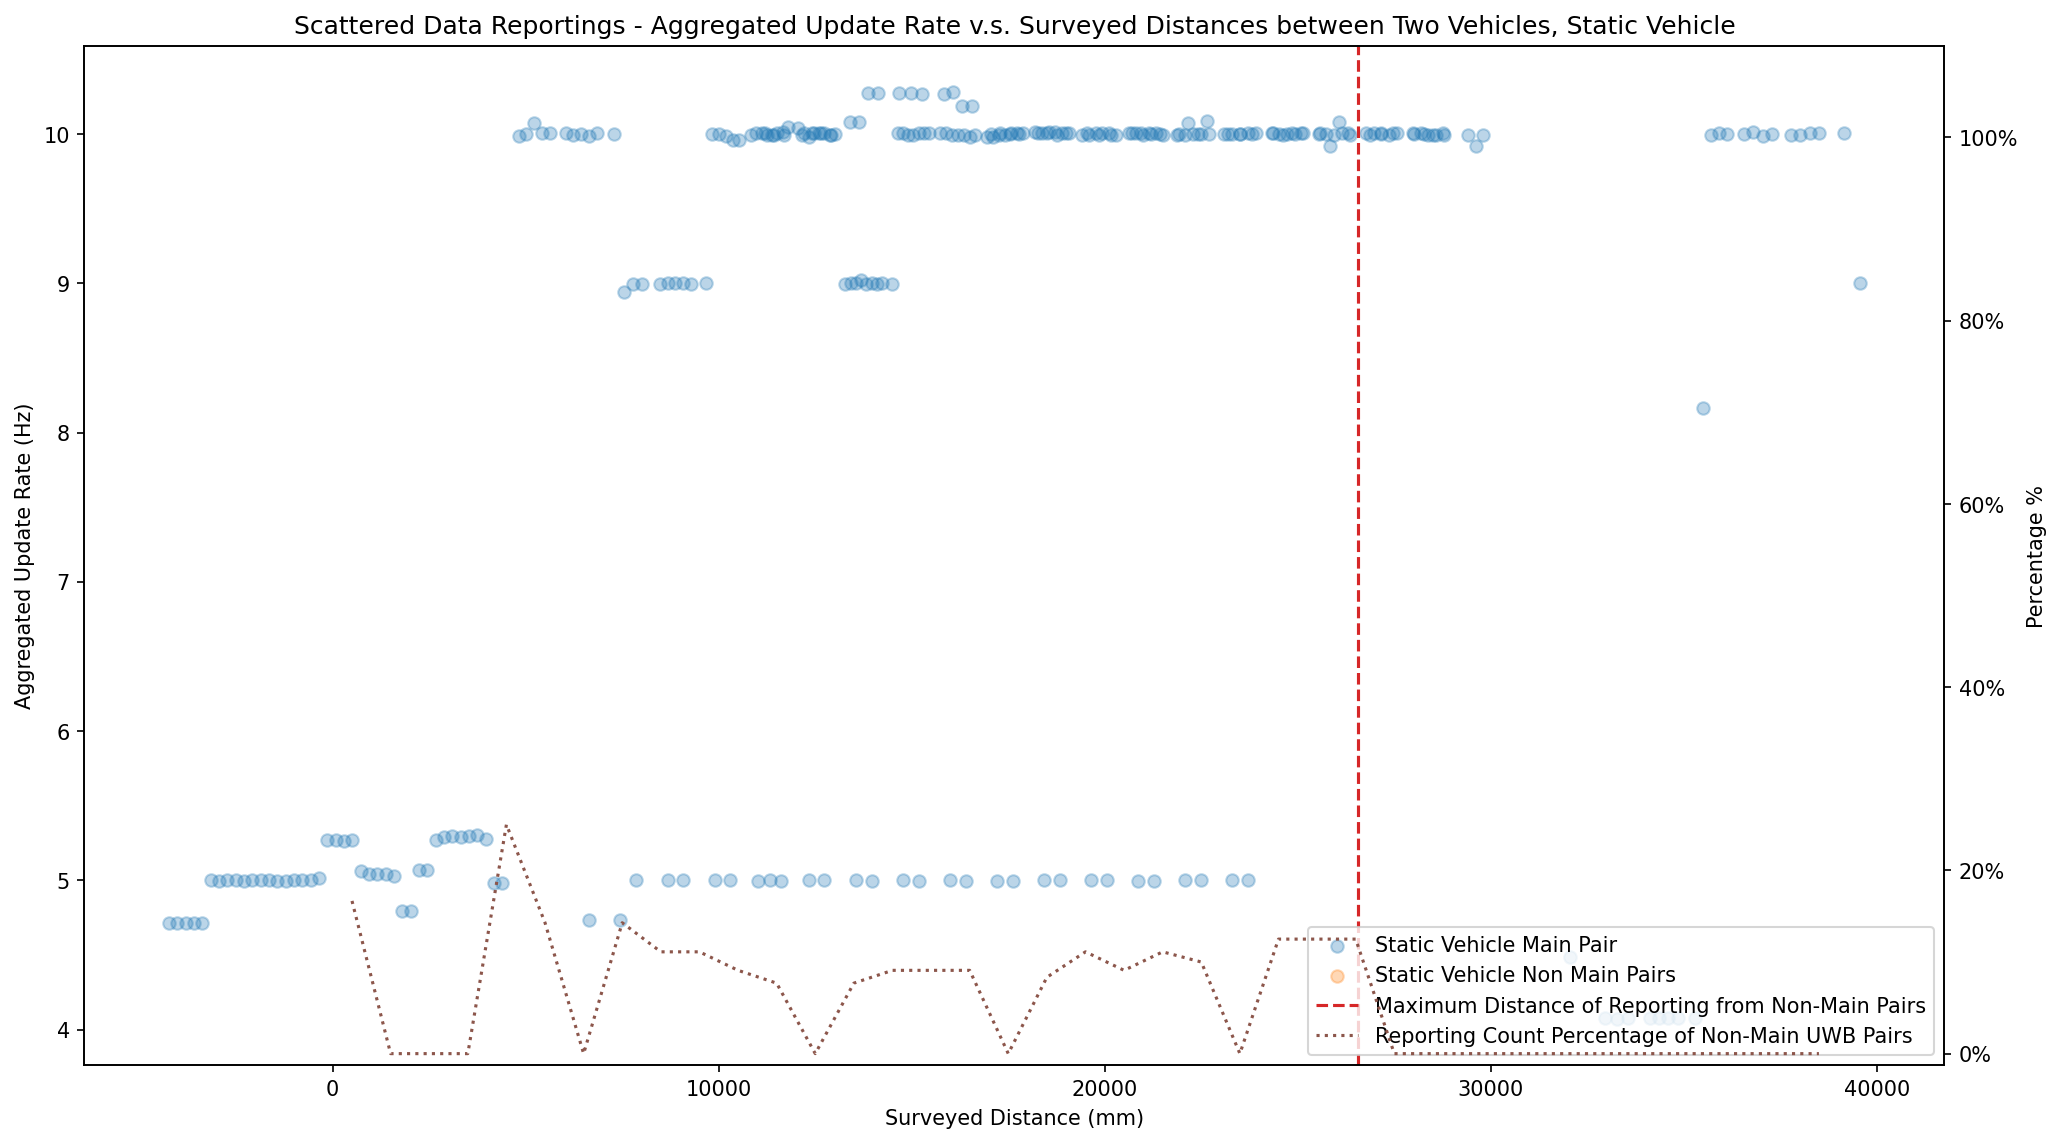

In [9]:
binsize = 1000
figure = plt.figure(figsize=(16, 9), dpi=150)
ax = figure.add_subplot(111)

main_df = df_all_static_stats_dist_idx_moving_test[
    (df_all_static_stats_dist_idx_moving_test["Initiating Master"] == static_main_master) & 
    (df_all_static_stats_dist_idx_moving_test["Reporting Slave"] == static_focusing_slaves[0])
]
main_df = main_df[main_df.index.notnull()]

non_main_df = df_all_static_stats_dist_idx_moving_test[
    (df_all_static_stats_dist_idx_moving_test["Initiating Master"] != static_main_master) | 
    (df_all_static_stats_dist_idx_moving_test["Reporting Slave"] != static_focusing_slaves[0])
]
non_main_df = non_main_df[non_main_df.index.notnull()]

# Static Aggregated
main_scatter = ax.scatter(main_df.index, 
                          main_df["Aggregated Update Rate (Hz)"], 
                          label="Static Vehicle Main Pair",
                          color="C0",
                          alpha=0.3)
           
# Static Aggregated
non_main_scatter = ax.scatter(non_main_df.index, 
                              non_main_df["Aggregated Update Rate (Hz)"], 
                              label="Static Vehicle Non Main Pairs",
                              color="C1",
                              alpha=0.3)
v_line = ax.axvline(non_main_df.index.max(), 
                    linestyle="--", 
                    color="C3",
                    label="Maximum Distance of Reporting from Non-Main Pairs")
ax.set_xlabel("Surveyed Distance (mm)")
ax.set_ylabel("Aggregated Update Rate (Hz)")
ax.set_title("Scattered Data Reportings - Aggregated Update Rate v.s. Surveyed Distances between Two Vehicles, Static Vehicle")

ax2 = ax.twinx()
bins = np.arange(0, max(main_df.index.max(), non_main_df.index.max()), binsize)
_percent_df_main = pd.DataFrame(
    data=main_df[["Instant Update Rate (Hz)", "Aggregated Update Rate (Hz)"]].groupby(pd.cut(main_df.index, bins)).size(),
    columns=["count"])
_percent_df_non_main = pd.DataFrame(
    data=non_main_df[["Instant Update Rate (Hz)", "Aggregated Update Rate (Hz)"]].groupby(pd.cut(non_main_df.index, bins)).size(),
    columns=["count"])
_percent_df = pd.DataFrame()
_percent_df["total"] = _percent_df_main["count"] + _percent_df_non_main["count"]
_percent_df["main count"] = _percent_df_main["count"]
_percent_df["non main count"] = _percent_df_non_main["count"]
_percent_df["percent non main"] = _percent_df["non main count"] / _percent_df["total"]
_percent_df['mid'] = [i.mid for i in _percent_df.index.array]

percent_line = ax2.plot(_percent_df[_percent_df["percent non main"] >= 0]["mid"], 
                        _percent_df[_percent_df["percent non main"] >= 0]["percent non main"],
                        label="Reporting Count Percentage of Non-Main UWB Pairs",
                        linestyle=":",
                        color="C5")
ax2.set_ylabel("Percentage %")
l = ax.legend([main_scatter, non_main_scatter, v_line, percent_line[0]], 
              [main_scatter.get_label(), non_main_scatter.get_label(), v_line.get_label(), percent_line[0].get_label()],
              loc='lower right')
ax2.set_ylim(top=1.1)
_yticks = ax2.get_yticks()
ax2.set_yticklabels(['{:,.0%}'.format(x) for x in _yticks])
plt.show()

### Moving Vehicle

C:\Users\wangz\.conda\envs\py37iot\lib\site-packages\ipykernel_launcher.py:63: UserWarning: FixedFormatter should only be used together with FixedLocator


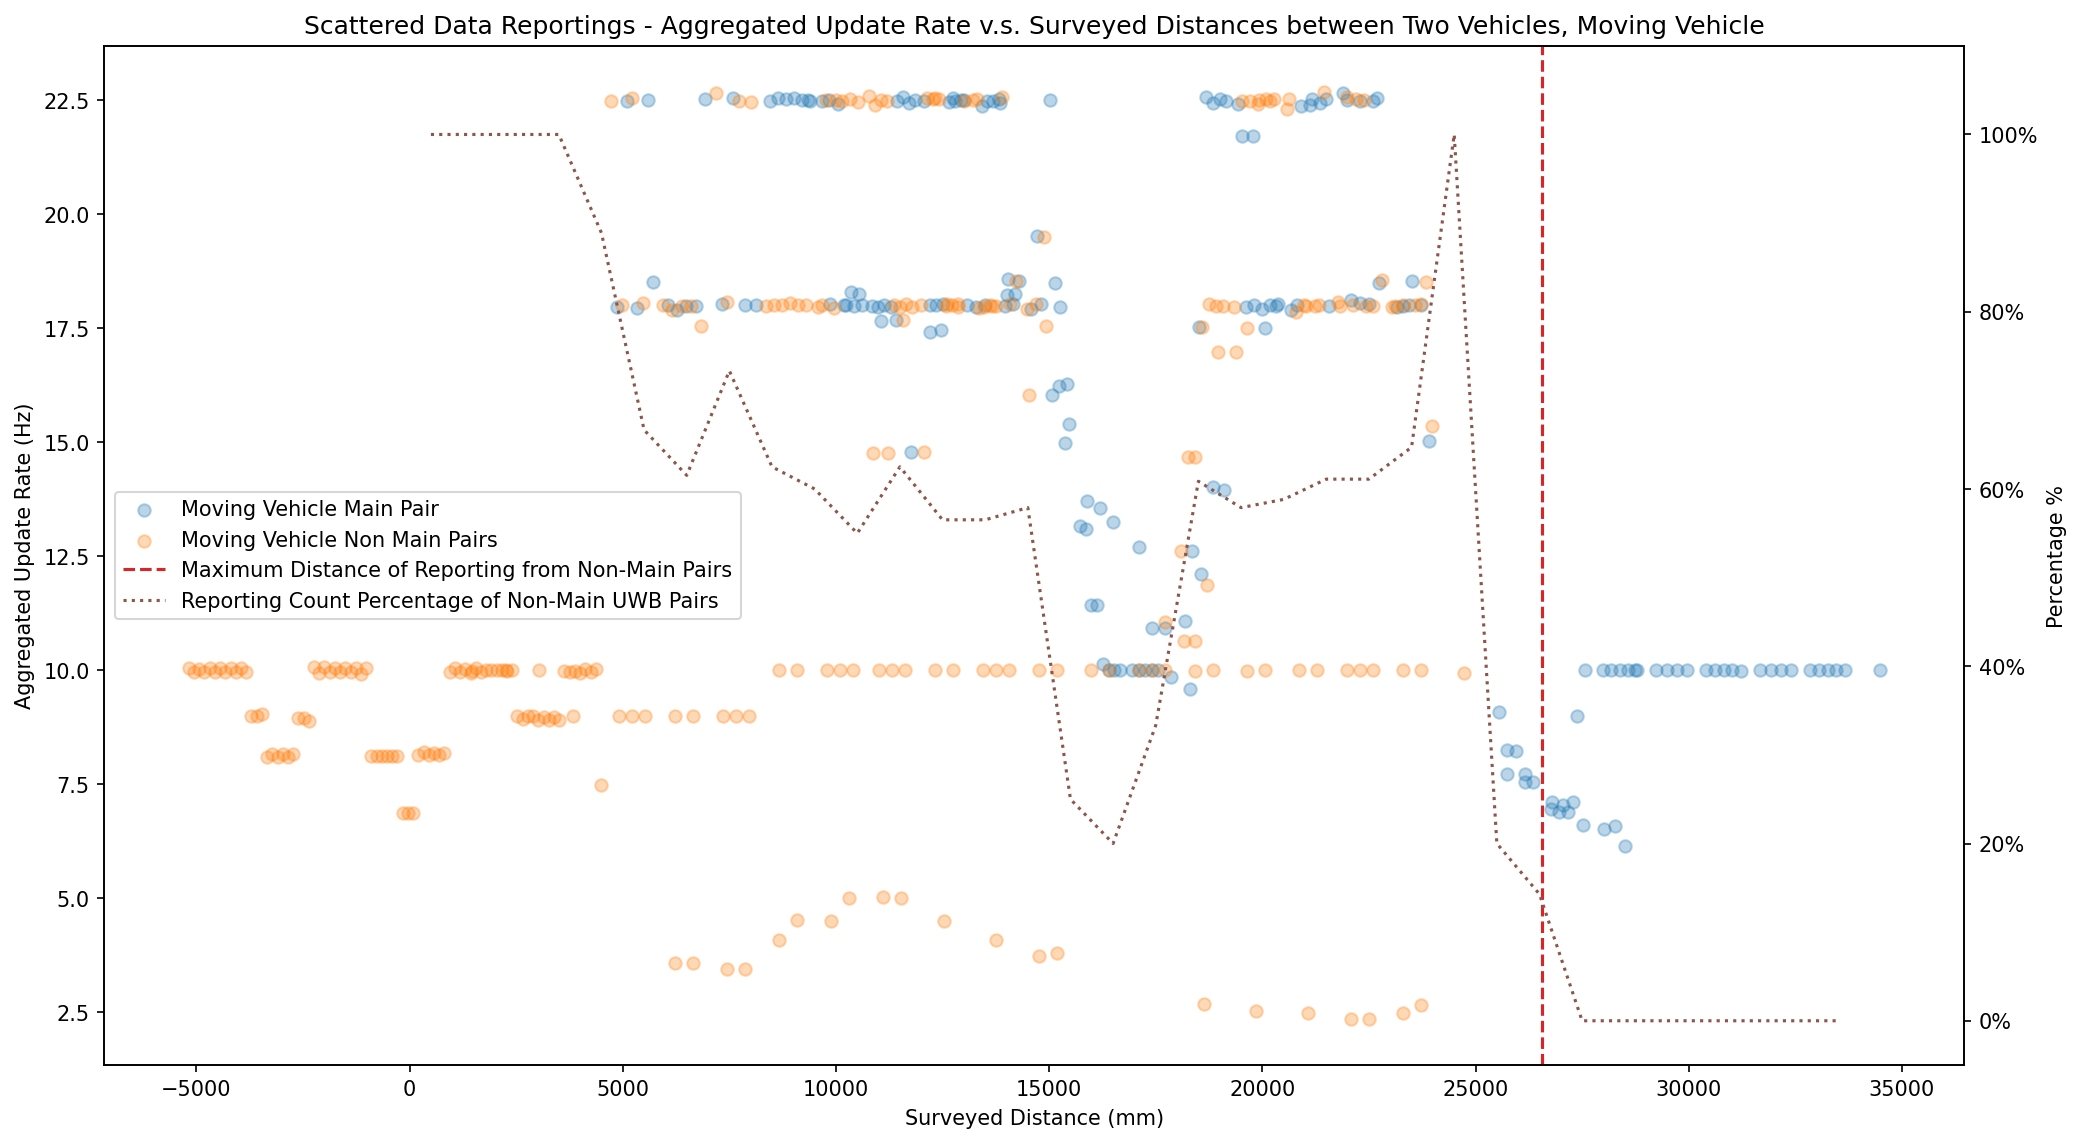

In [10]:
binsize = 1000
figure = plt.figure(figsize=(16, 9), dpi=150)
ax = figure.add_subplot(111)

main_df = df_all_moving_stats_dist_idx_moving_test[
    (df_all_moving_stats_dist_idx_moving_test["Initiating Master"] == moving_main_master) & 
    (df_all_moving_stats_dist_idx_moving_test["Reporting Slave"] == moving_focusing_slaves[0])
]
main_df = main_df[main_df.index.notnull()]

non_main_df = df_all_moving_stats_dist_idx_moving_test[
    (df_all_moving_stats_dist_idx_moving_test["Initiating Master"] != moving_main_master) | 
    (df_all_moving_stats_dist_idx_moving_test["Reporting Slave"] != moving_focusing_slaves[0])
]
non_main_df = non_main_df[non_main_df.index.notnull()]

# Moving Aggregated
main_scatter = ax.scatter(main_df.index, 
                          main_df["Aggregated Update Rate (Hz)"], 
                          label="Moving Vehicle Main Pair",
                          color="C0",
                          alpha=0.3)
           
# Moving Aggregated
non_main_scatter = ax.scatter(non_main_df.index, 
                              non_main_df["Aggregated Update Rate (Hz)"], 
                              label="Moving Vehicle Non Main Pairs",
                              color="C1",
                              alpha=0.3)
v_line = ax.axvline(non_main_df.index.max(), 
                    linestyle="--", 
                    color="C3",
                    label="Maximum Distance of Reporting from Non-Main Pairs")
ax.set_xlabel("Surveyed Distance (mm)")
ax.set_ylabel("Aggregated Update Rate (Hz)")
ax.set_title("Scattered Data Reportings - Aggregated Update Rate v.s. Surveyed Distances between Two Vehicles, Moving Vehicle")

ax2 = ax.twinx()
bins = np.arange(0, max(main_df.index.max(), non_main_df.index.max()), binsize)
_percent_df_main = pd.DataFrame(
    data=main_df[["Instant Update Rate (Hz)", "Aggregated Update Rate (Hz)"]].groupby(pd.cut(main_df.index, bins)).size(),
    columns=["count"])
_percent_df_non_main = pd.DataFrame(
    data=non_main_df[["Instant Update Rate (Hz)", "Aggregated Update Rate (Hz)"]].groupby(pd.cut(non_main_df.index, bins)).size(),
    columns=["count"])
_percent_df = pd.DataFrame()
_percent_df["total"] = _percent_df_main["count"] + _percent_df_non_main["count"]
_percent_df["main count"] = _percent_df_main["count"]
_percent_df["non main count"] = _percent_df_non_main["count"]
_percent_df["percent non main"] = _percent_df["non main count"] / _percent_df["total"]
_percent_df['mid'] = [i.mid for i in _percent_df.index.array]

percent_line = ax2.plot(_percent_df[_percent_df["percent non main"] >= 0]["mid"], 
                        _percent_df[_percent_df["percent non main"] >= 0]["percent non main"],
                        label="Reporting Count Percentage of Non-Main UWB Pairs",
                        linestyle=":",
                        color="C5")
ax2.set_ylabel("Percentage %")
l = ax.legend([main_scatter, non_main_scatter, v_line, percent_line[0]], 
              [main_scatter.get_label(), non_main_scatter.get_label(), v_line.get_label(), percent_line[0].get_label()])
ax2.set_ylim(top=1.1)
_yticks = ax2.get_yticks()
ax2.set_yticklabels(['{:,.0%}'.format(x) for x in _yticks])
plt.show()

## Virtual Moving Test 2 - Normalized Update Rate (Aggregated Overall) v.s. Surveyed Distances

### Both Vehicles

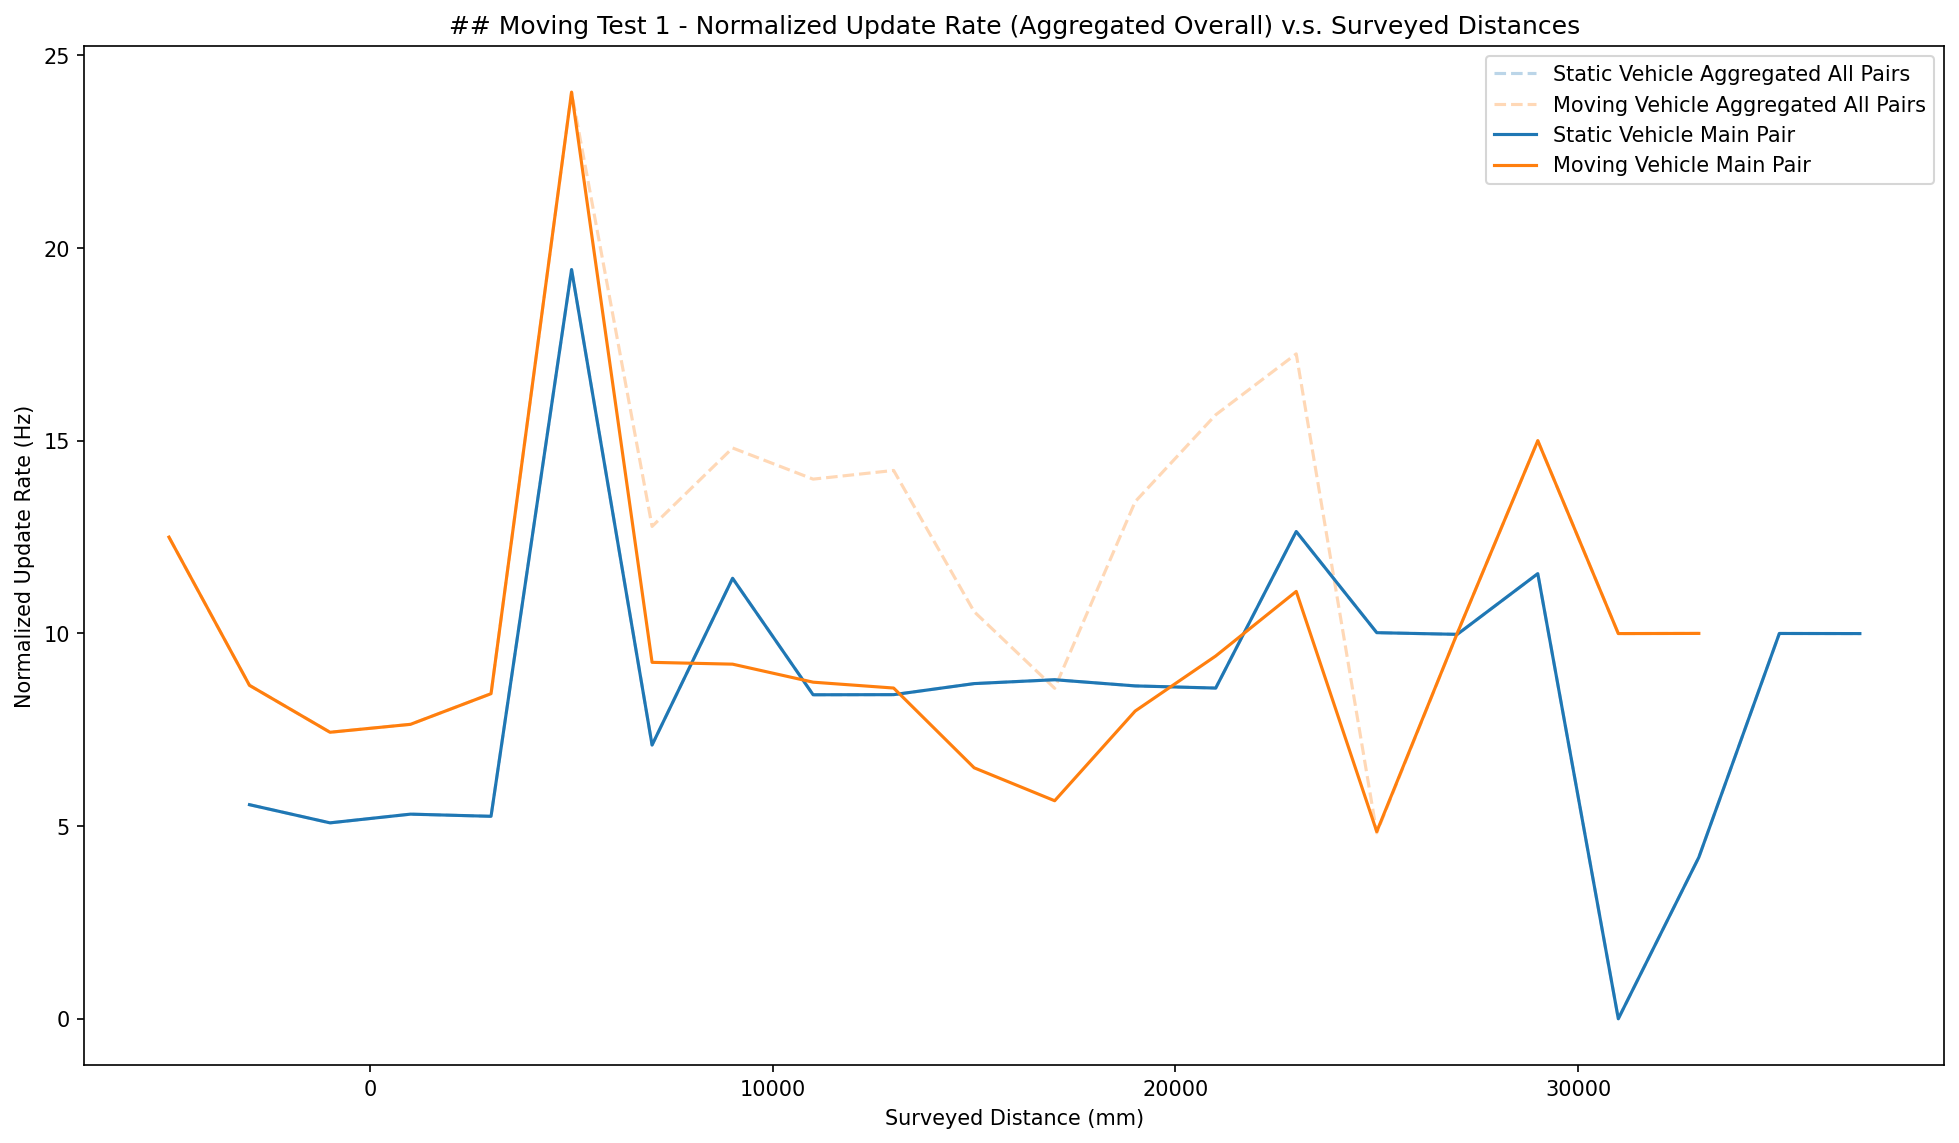

In [11]:
dist_bin = 2000
static_grouped_list = []
categorical_idx_static = None
for df in static_stats_time_idx:
    df = df[df['Instant Speed by Marker (mph)'].notnull()]
    if df.shape[0] == 0:
        continue
    else: 
        if df["Surveyed Distance (mm)"].dropna().is_monotonic_increasing \
            or df["Surveyed Distance (mm)"].dropna().is_monotonic_decreasing:
            df = df.set_index("Surveyed Distance (mm)")
            bins = np.arange(dist_bin * (min(df.index) // dist_bin), 
                             dist_bin * ((max(df.index) + dist_bin) // dist_bin + 1), 
                             dist_bin)
            interpolated_idx_df = pd.DataFrame(index=bins)
            inserted_idx_df = pd.concat([df, interpolated_idx_df]).sort_index()
            inserted_idx_df["Timestamp Norm (s)"] = inserted_idx_df["Timestamp Norm (s)"].interpolate(method="linear", limit_direction='both', limit_area='inside')
            interpolated_idx_df["Timestamp Norms (s)"] = inserted_idx_df["Timestamp Norm (s)"]
            grouped_df = pd.DataFrame()
            grouped_df["min timestamp"] = df["Timestamp Norm (s)"].groupby(pd.cut(df.index, bins)).min()
            grouped_df["max timestamp"] = df["Timestamp Norm (s)"].groupby(pd.cut(df.index, bins)).max()
            grouped_df["avg timestamp"] = df["Timestamp Norm (s)"].groupby(pd.cut(df.index, bins)).mean()
            grouped_df["reporting counts"] = df["Timestamp Norm (s)"].groupby(pd.cut(df.index, bins)).count()
            
            # Interpolate values only for the inside NaN gaps. 
            grouped_df["avg timestamp"] = grouped_df["avg timestamp"].interpolate(method='linear', 
                                                                                  limit_direction='both', 
                                                                                  limit_area="inside").sort_index()
            grouped_df["left interpolated timestamp"] = interpolated_idx_df.iloc[:-1]["Timestamp Norms (s)"].array
            grouped_df["right interpolated timestamp"] = interpolated_idx_df.iloc[1:]["Timestamp Norms (s)"].array
            grouped_df["duration"] = abs(grouped_df["left interpolated timestamp"] - grouped_df['right interpolated timestamp'])
            static_grouped_list.append(grouped_df)
            if categorical_idx_static is None:
                categorical_idx_static = grouped_df.index
            else:
                categorical_idx_static = categorical_idx_static.union(grouped_df.index)
static_df_counts = pd.DataFrame(index=categorical_idx_static, columns=['reporting counts', 'duration'])
static_df_counts['reporting counts'] = 0
static_df_counts['duration'] = 0
for df in static_grouped_list:
    df = df.reindex_like(static_df_counts).fillna(0)
    static_df_counts['reporting counts'] = static_df_counts['reporting counts'] + df['reporting counts']
    static_df_counts['duration'] = static_df_counts['duration'] + df['duration']

moving_grouped_list = []
categorical_idx_moving = None
for df in moving_stats_time_idx:
    df = df[df["Surveyed Distance (mm)"].notnull()]
    if df.shape[0] == 0:
        continue
    else: 
        if df["Surveyed Distance (mm)"].dropna().is_monotonic_increasing \
            or df["Surveyed Distance (mm)"].dropna().is_monotonic_decreasing:
            df = df.set_index("Surveyed Distance (mm)")
            bins = np.arange(dist_bin * (min(df.index) // dist_bin), 
                             dist_bin * ((max(df.index) + dist_bin) // dist_bin + 1), 
                             dist_bin)
            interpolated_idx_df = pd.DataFrame(index=bins)
            inserted_idx_df = pd.concat([df, interpolated_idx_df]).sort_index()
            inserted_idx_df["Timestamp Norm (s)"] = inserted_idx_df["Timestamp Norm (s)"].interpolate(method="linear", limit_direction='both', limit_area='inside')
            interpolated_idx_df["Timestamp Norms (s)"] = inserted_idx_df["Timestamp Norm (s)"]
            grouped_df = pd.DataFrame()
            grouped_df["min timestamp"] = df["Timestamp Norm (s)"].groupby(pd.cut(df.index, bins)).min()
            grouped_df["max timestamp"] = df["Timestamp Norm (s)"].groupby(pd.cut(df.index, bins)).max()
            grouped_df["avg timestamp"] = df["Timestamp Norm (s)"].groupby(pd.cut(df.index, bins)).mean()
            grouped_df["reporting counts"] = df["Timestamp Norm (s)"].groupby(pd.cut(df.index, bins)).count()
            
            # Interpolate values only for the inside NaN gaps. 
            grouped_df["avg timestamp"] = grouped_df["avg timestamp"].interpolate(method='linear', 
                                                                                  limit_direction='both', 
                                                                                  limit_area="inside").sort_index()
            grouped_df["left interpolated timestamp"] = interpolated_idx_df.iloc[:-1]["Timestamp Norms (s)"].array
            grouped_df["right interpolated timestamp"] = interpolated_idx_df.iloc[1:]["Timestamp Norms (s)"].array
            grouped_df["duration"] = abs(grouped_df["left interpolated timestamp"] - grouped_df['right interpolated timestamp'])
            moving_grouped_list.append(grouped_df)
            if categorical_idx_moving is None:
                categorical_idx_moving = grouped_df.index
            else:
                categorical_idx_moving = categorical_idx_moving.union(grouped_df.index)

moving_df_counts = pd.DataFrame(index=categorical_idx_moving, columns=['reporting counts', 'duration'])
moving_df_counts['reporting counts'] = 0
moving_df_counts['duration'] = 0
for df in moving_grouped_list:
    df = df.reindex_like(moving_df_counts).fillna(0)
    moving_df_counts['reporting counts'] = moving_df_counts['reporting counts'] + df['reporting counts']
    moving_df_counts['duration'] = moving_df_counts['duration'] + df['duration']

################################################################################
# Aggregated Above
################################################################################
################################################################################
# Main Pair Below
################################################################################
    
static_grouped_list_main_pair = []
categorical_idx_static_main_pair = None
for df in static_stats_time_idx:
    df = df[df['Instant Speed by Marker (mph)'].notnull()]
    if df.shape[0] == 0:
        continue
    else: 
        if df["Surveyed Distance (mm)"].dropna().is_monotonic_increasing \
            or df["Surveyed Distance (mm)"].dropna().is_monotonic_decreasing:
            for master, slave_list in static_master_slave_mapping.items():
                for slave in slave_list:
                    # Main Pair
                    pairwise_df = df.set_index("Surveyed Distance (mm)")
                    pairwise_df = pairwise_df[(pairwise_df["Initiating Master"] == master) & (pairwise_df["Reporting Slave"] == slave)]
                    if pairwise_df.index.empty:
                        continue
                    bins = np.arange(dist_bin * (min(pairwise_df.index) // dist_bin), 
                                     dist_bin * ((max(pairwise_df.index) + dist_bin) // dist_bin + 1), 
                                     dist_bin)
                    interpolated_idx_df = pd.DataFrame(index=bins)
                    inserted_idx_df = pd.concat([pairwise_df, interpolated_idx_df]).sort_index()
                    inserted_idx_df["Timestamp Norm (s)"] = inserted_idx_df["Timestamp Norm (s)"].interpolate(method="linear", limit_direction='both', limit_area='inside')
                    interpolated_idx_df["Timestamp Norms (s)"] = inserted_idx_df["Timestamp Norm (s)"]
                    grouped_df = pd.DataFrame()
                    grouped_df["min timestamp"] = pairwise_df["Timestamp Norm (s)"].groupby(pd.cut(pairwise_df.index, bins)).min()
                    grouped_df["max timestamp"] = pairwise_df["Timestamp Norm (s)"].groupby(pd.cut(pairwise_df.index, bins)).max()
                    grouped_df["avg timestamp"] = pairwise_df["Timestamp Norm (s)"].groupby(pd.cut(pairwise_df.index, bins)).mean()
                    grouped_df["reporting counts"] = pairwise_df["Timestamp Norm (s)"].groupby(pd.cut(pairwise_df.index, bins)).count()

                    # Interpolate values only for the inside NaN gaps. 
                    grouped_df["avg timestamp"] = grouped_df["avg timestamp"].interpolate(method='linear', 
                                                                                          limit_direction='both', 
                                                                                          limit_area="inside").sort_index()
                    grouped_df["left interpolated timestamp"] = interpolated_idx_df.iloc[:-1]["Timestamp Norms (s)"].array
                    grouped_df["right interpolated timestamp"] = interpolated_idx_df.iloc[1:]["Timestamp Norms (s)"].array
                    grouped_df["duration"] = abs(grouped_df["left interpolated timestamp"] - grouped_df['right interpolated timestamp'])
                    static_grouped_list_main_pair.append(grouped_df)
                    if categorical_idx_static_main_pair is None:
                        categorical_idx_static_main_pair = grouped_df.index
                    else:
                        categorical_idx_static_main_pair = categorical_idx_static_main_pair.union(grouped_df.index)
static_df_counts_main_pair = pd.DataFrame(index=categorical_idx_static_main_pair, columns=['reporting counts', 'duration'])
static_df_counts_main_pair['reporting counts'] = 0
static_df_counts_main_pair['duration'] = 0
for df in static_grouped_list_main_pair:
    df = df.reindex_like(static_df_counts).fillna(0)
    static_df_counts_main_pair['reporting counts'] = static_df_counts_main_pair['reporting counts'] + df['reporting counts']
    static_df_counts_main_pair['duration'] = static_df_counts_main_pair['duration'] + df['duration']

moving_grouped_list_main_pair = []
categorical_idx_moving_main_pair = None
for df in moving_stats_time_idx:
    df = df[df["Surveyed Distance (mm)"].notnull()]
    if df.shape[0] == 0:
        continue
    else: 
        if df["Surveyed Distance (mm)"].dropna().is_monotonic_increasing \
            or df["Surveyed Distance (mm)"].dropna().is_monotonic_decreasing:
            for master, slave_list in moving_master_slave_mapping.items():
                for slave in slave_list:
                    # Main Pair
                    pairwise_df = df.set_index("Surveyed Distance (mm)")
                    pairwise_df = pairwise_df[(pairwise_df["Initiating Master"] == master) & (pairwise_df["Reporting Slave"] == slave)]
                    if pairwise_df.index.empty:
                        continue
                    bins = np.arange(dist_bin * (min(pairwise_df.index) // dist_bin), 
                                     dist_bin * ((max(pairwise_df.index) + dist_bin) // dist_bin + 1), 
                                     dist_bin)
                    interpolated_idx_df = pd.DataFrame(index=bins)
                    inserted_idx_df = pd.concat([pairwise_df, interpolated_idx_df]).sort_index()
                    inserted_idx_df["Timestamp Norm (s)"] = inserted_idx_df["Timestamp Norm (s)"].interpolate(method="linear", limit_direction='both', limit_area='inside')
                    interpolated_idx_df["Timestamp Norms (s)"] = inserted_idx_df["Timestamp Norm (s)"]
                    grouped_df = pd.DataFrame()
                    grouped_df["min timestamp"] = pairwise_df["Timestamp Norm (s)"].groupby(pd.cut(pairwise_df.index, bins)).min()
                    grouped_df["max timestamp"] = pairwise_df["Timestamp Norm (s)"].groupby(pd.cut(pairwise_df.index, bins)).max()
                    grouped_df["avg timestamp"] = pairwise_df["Timestamp Norm (s)"].groupby(pd.cut(pairwise_df.index, bins)).mean()
                    grouped_df["reporting counts"] = pairwise_df["Timestamp Norm (s)"].groupby(pd.cut(pairwise_df.index, bins)).count()

                    # Interpolate values only for the inside NaN gaps. 
                    grouped_df["avg timestamp"] = grouped_df["avg timestamp"].interpolate(method='linear', 
                                                                                          limit_direction='both', 
                                                                                          limit_area="inside").sort_index()
                    grouped_df["left interpolated timestamp"] = interpolated_idx_df.iloc[:-1]["Timestamp Norms (s)"].array
                    grouped_df["right interpolated timestamp"] = interpolated_idx_df.iloc[1:]["Timestamp Norms (s)"].array
                    grouped_df["duration"] = abs(grouped_df["left interpolated timestamp"] - grouped_df['right interpolated timestamp'])
                    moving_grouped_list_main_pair.append(grouped_df)
                    if categorical_idx_moving_main_pair is None:
                        categorical_idx_moving_main_pair = grouped_df.index
                    else:
                        categorical_idx_moving_main_pair = categorical_idx_moving_main_pair.union(grouped_df.index)
moving_df_counts_main_pair = pd.DataFrame(index=categorical_idx_moving, columns=['reporting counts', 'duration'])
moving_df_counts_main_pair['reporting counts'] = 0
moving_df_counts_main_pair['duration'] = 0
for df in moving_grouped_list_main_pair:
    df = df.reindex_like(moving_df_counts).fillna(0)
    moving_df_counts_main_pair['reporting counts'] = moving_df_counts_main_pair['reporting counts'] + df['reporting counts']
    moving_df_counts_main_pair['duration'] = moving_df_counts_main_pair['duration'] + df['duration']

figure = plt.figure(figsize=(16, 9), dpi=150)
ax = figure.add_subplot(111)
ax.plot([i.mid for i in 
         (static_df_counts['reporting counts'] / static_df_counts['duration']).index.array], 
        static_df_counts['reporting counts'] / static_df_counts['duration'],
        label="Static Vehicle Aggregated All Pairs",color="C0", alpha=0.3, linestyle='--')
ax.plot([i.mid for i in 
         (moving_df_counts['reporting counts'] / moving_df_counts['duration']).index.array], 
        moving_df_counts['reporting counts'] / moving_df_counts['duration'],
        label="Moving Vehicle Aggregated All Pairs",color="C1", alpha=0.3, linestyle='--')
    
ax.plot([i.mid for i in 
         (static_df_counts_main_pair['reporting counts'] / static_df_counts_main_pair['duration']).index.array], 
        static_df_counts_main_pair['reporting counts'] / static_df_counts_main_pair['duration'],
        label="Static Vehicle Main Pair", color="C0")
ax.plot([i.mid for i in 
         (moving_df_counts_main_pair['reporting counts'] / moving_df_counts_main_pair['duration']).index.array], 
        moving_df_counts_main_pair['reporting counts'] / moving_df_counts_main_pair['duration'],
        label="Moving Vehicle Main Pair", color="C1")

ax.legend()
ax.set_ylabel("Normalized Update Rate (Hz)")
ax.set_xlabel("Surveyed Distance (mm)")
ax.set_title("## Moving Test 1 - Normalized Update Rate (Aggregated Overall) v.s. Surveyed Distances")
plt.show()

## Virtual Moving Test 2 - Reporting Count Bar Chart v.s. Surveyed Distances

### Static Vehicle

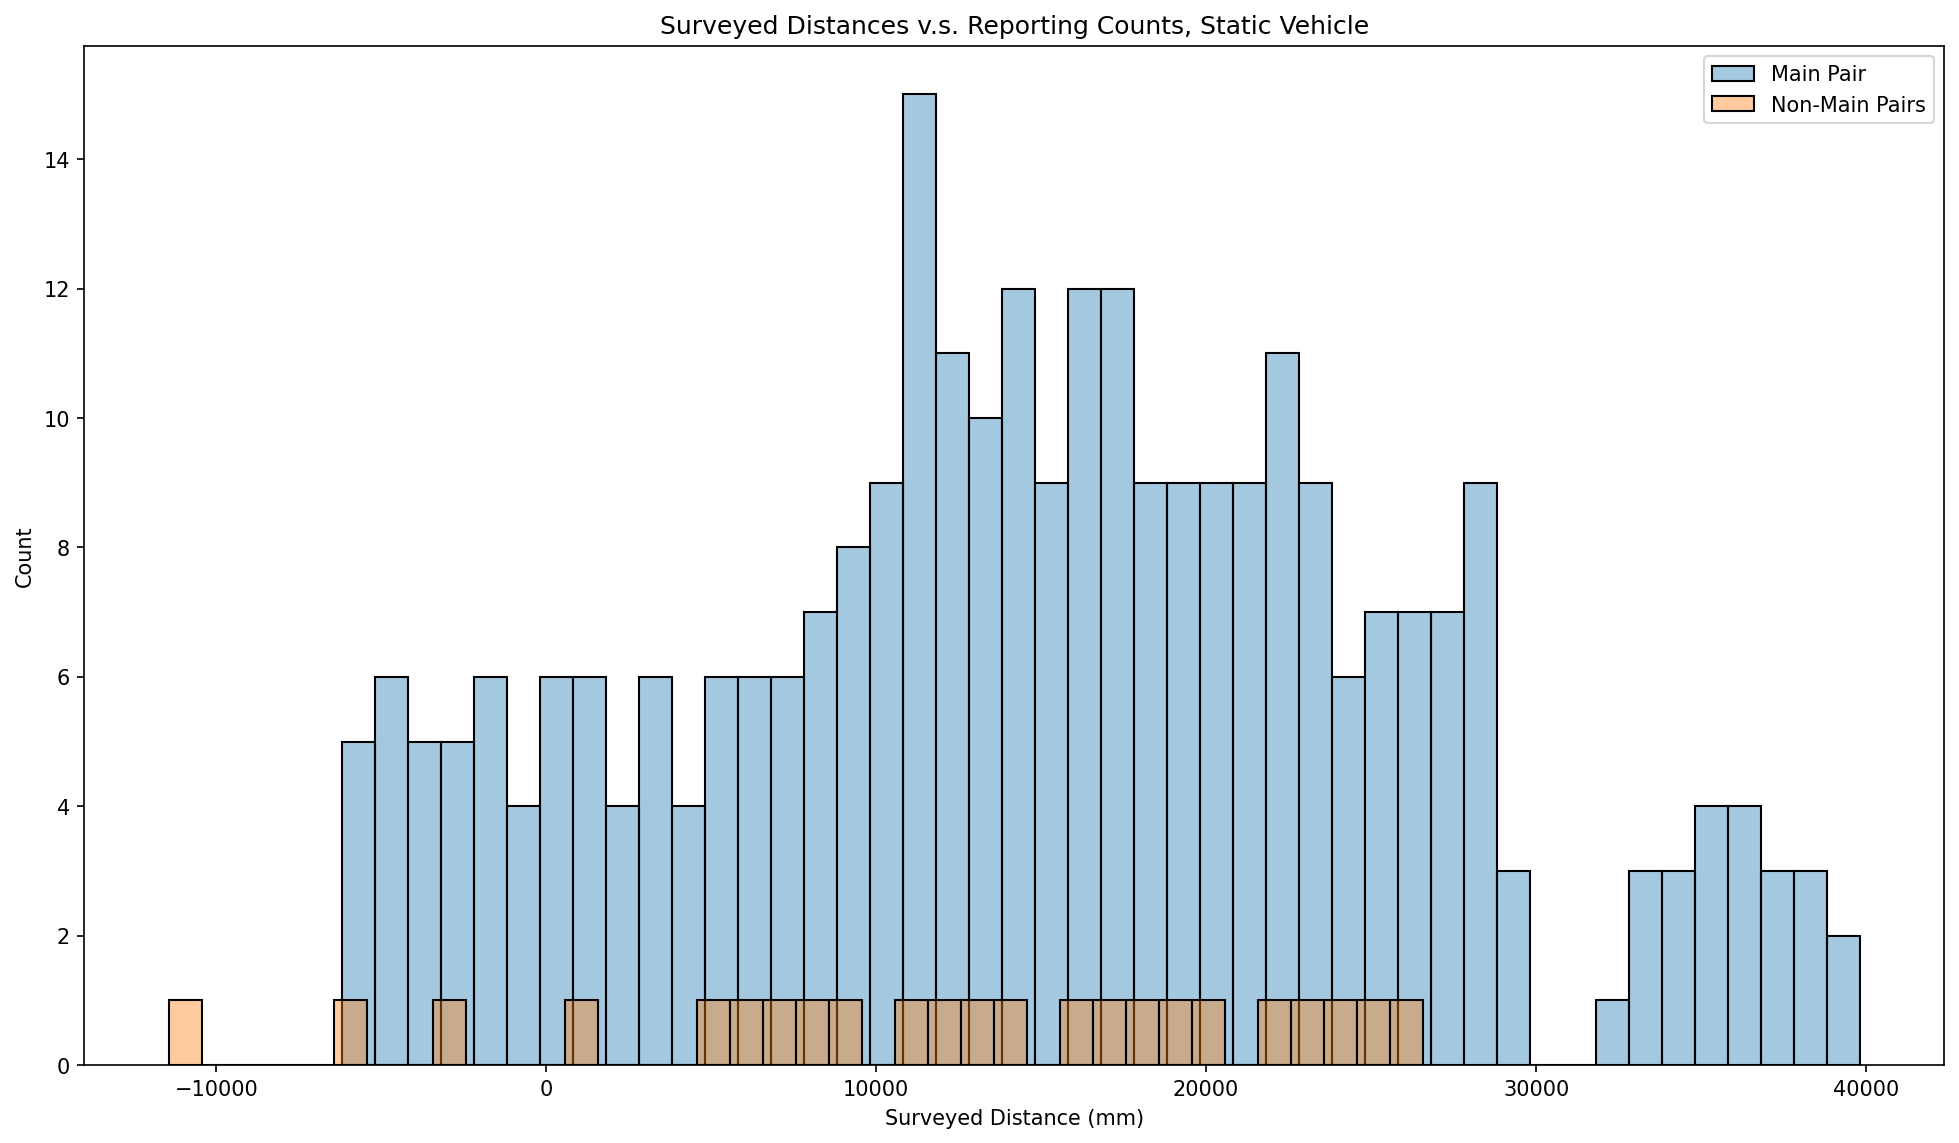

In [12]:
dist_bin = 1000

static_veh_main_pair = (df_all_static_stats_time_idx_moving_test[
    (df_all_static_stats_time_idx_moving_test["Initiating Master"] == static_main_master) & 
    (df_all_static_stats_time_idx_moving_test["Reporting Slave"] == static_master_slave_mapping[static_main_master][0])]
    ).sort_index()

static_veh_non_main = (df_all_static_stats_time_idx_moving_test[
    (df_all_static_stats_time_idx_moving_test["Initiating Master"] != static_main_master) | 
    (df_all_static_stats_time_idx_moving_test["Reporting Slave"] != static_master_slave_mapping[static_main_master][0])]
    ).sort_index()

figure = plt.figure(figsize=(16, 9), dpi=150)
ax1 = figure.add_subplot(111)
# Static Main Pair
hist_1 = sns.histplot(data=static_veh_main_pair, 
                      x=static_veh_main_pair["Surveyed Distance (mm)"],
                      binwidth=dist_bin, 
                      ax=ax1, 
                      color="C0", 
                      alpha=0.4, 
                      label="Main Pair")

# Static Non-Main Pairs
hist_2 = sns.histplot(data=static_veh_non_main, 
                      x=static_veh_non_main["Surveyed Distance (mm)"],
                      binwidth=dist_bin, 
                      ax=ax1, 
                      color="C1", 
                      alpha=0.4, 
                      label="Non-Main Pairs")
ax1.set_title("Surveyed Distances v.s. Reporting Counts, Static Vehicle")
ax1.legend()
plt.show()

### Moving Vehicle

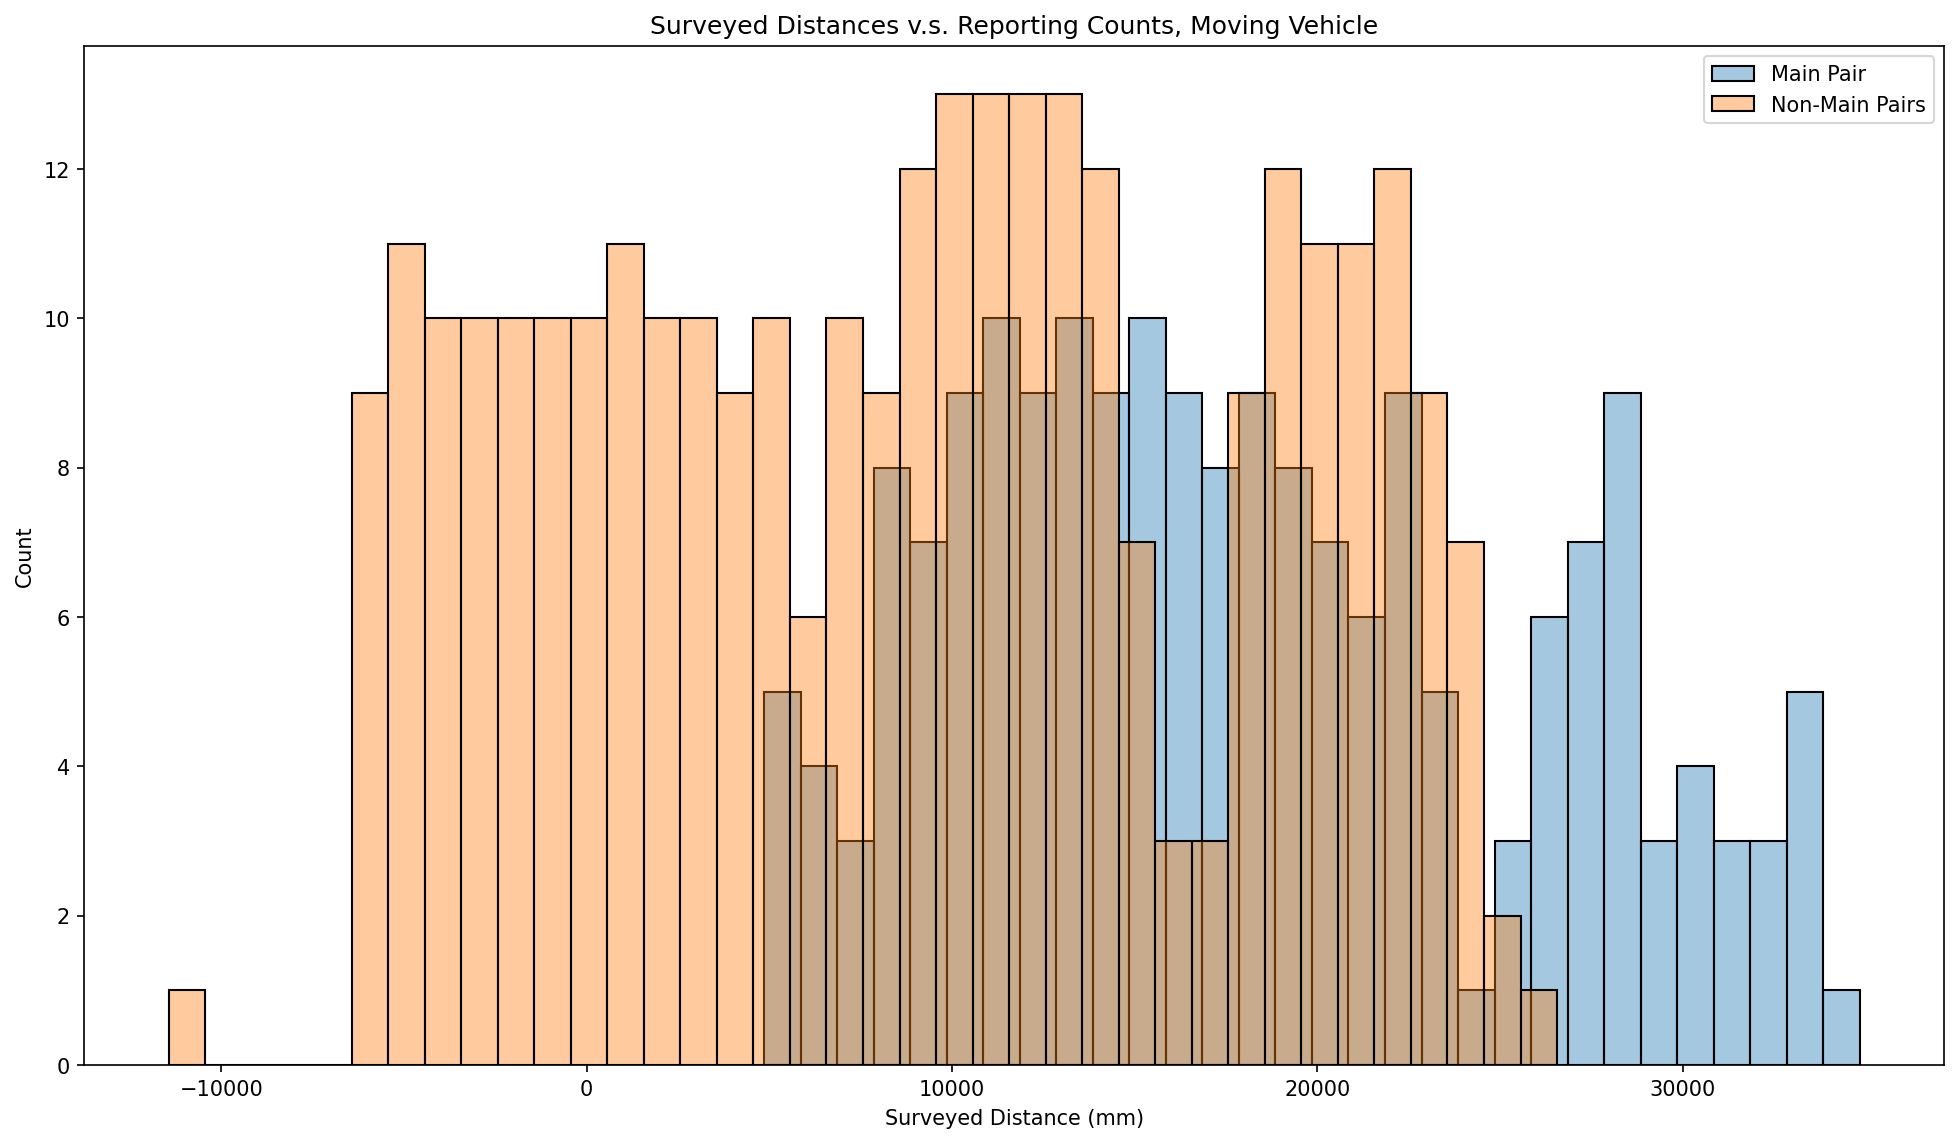

In [13]:
dist_bin = 1000

moving_veh_main_pair = (df_all_moving_stats_time_idx_moving_test[
    (df_all_moving_stats_time_idx_moving_test["Initiating Master"] == moving_main_master) & 
    (df_all_moving_stats_time_idx_moving_test["Reporting Slave"] == moving_master_slave_mapping[moving_main_master][0])]
    ).sort_index()

moving_veh_non_main = (df_all_moving_stats_time_idx_moving_test[
    (df_all_moving_stats_time_idx_moving_test["Initiating Master"] != moving_main_master) | 
    (df_all_moving_stats_time_idx_moving_test["Reporting Slave"] != moving_master_slave_mapping[moving_main_master][0])]
    ).sort_index()

figure = plt.figure(figsize=(16, 9), dpi=150)
ax1 = figure.add_subplot(111)
# Moving Main Pair
hist_1 = sns.histplot(data=moving_veh_main_pair, 
                      x=moving_veh_main_pair["Surveyed Distance (mm)"],
                      binwidth=dist_bin, 
                      ax=ax1, 
                      color="C0", 
                      alpha=0.4, 
                      label="Main Pair")

# Moving Non-Main Pairs
hist_2 = sns.histplot(data=moving_veh_non_main, 
                      x=moving_veh_non_main["Surveyed Distance (mm)"],
                      binwidth=dist_bin, 
                      ax=ax1, 
                      color="C1", 
                      alpha=0.4, 
                      label="Non-Main Pairs")
ax1.set_title("Surveyed Distances v.s. Reporting Counts, Moving Vehicle")
ax1.legend()
plt.show()

## Heat Map of Data Reporting Points when Instant Update Rate Cannot Reach 10Hz

### Static Vehicle

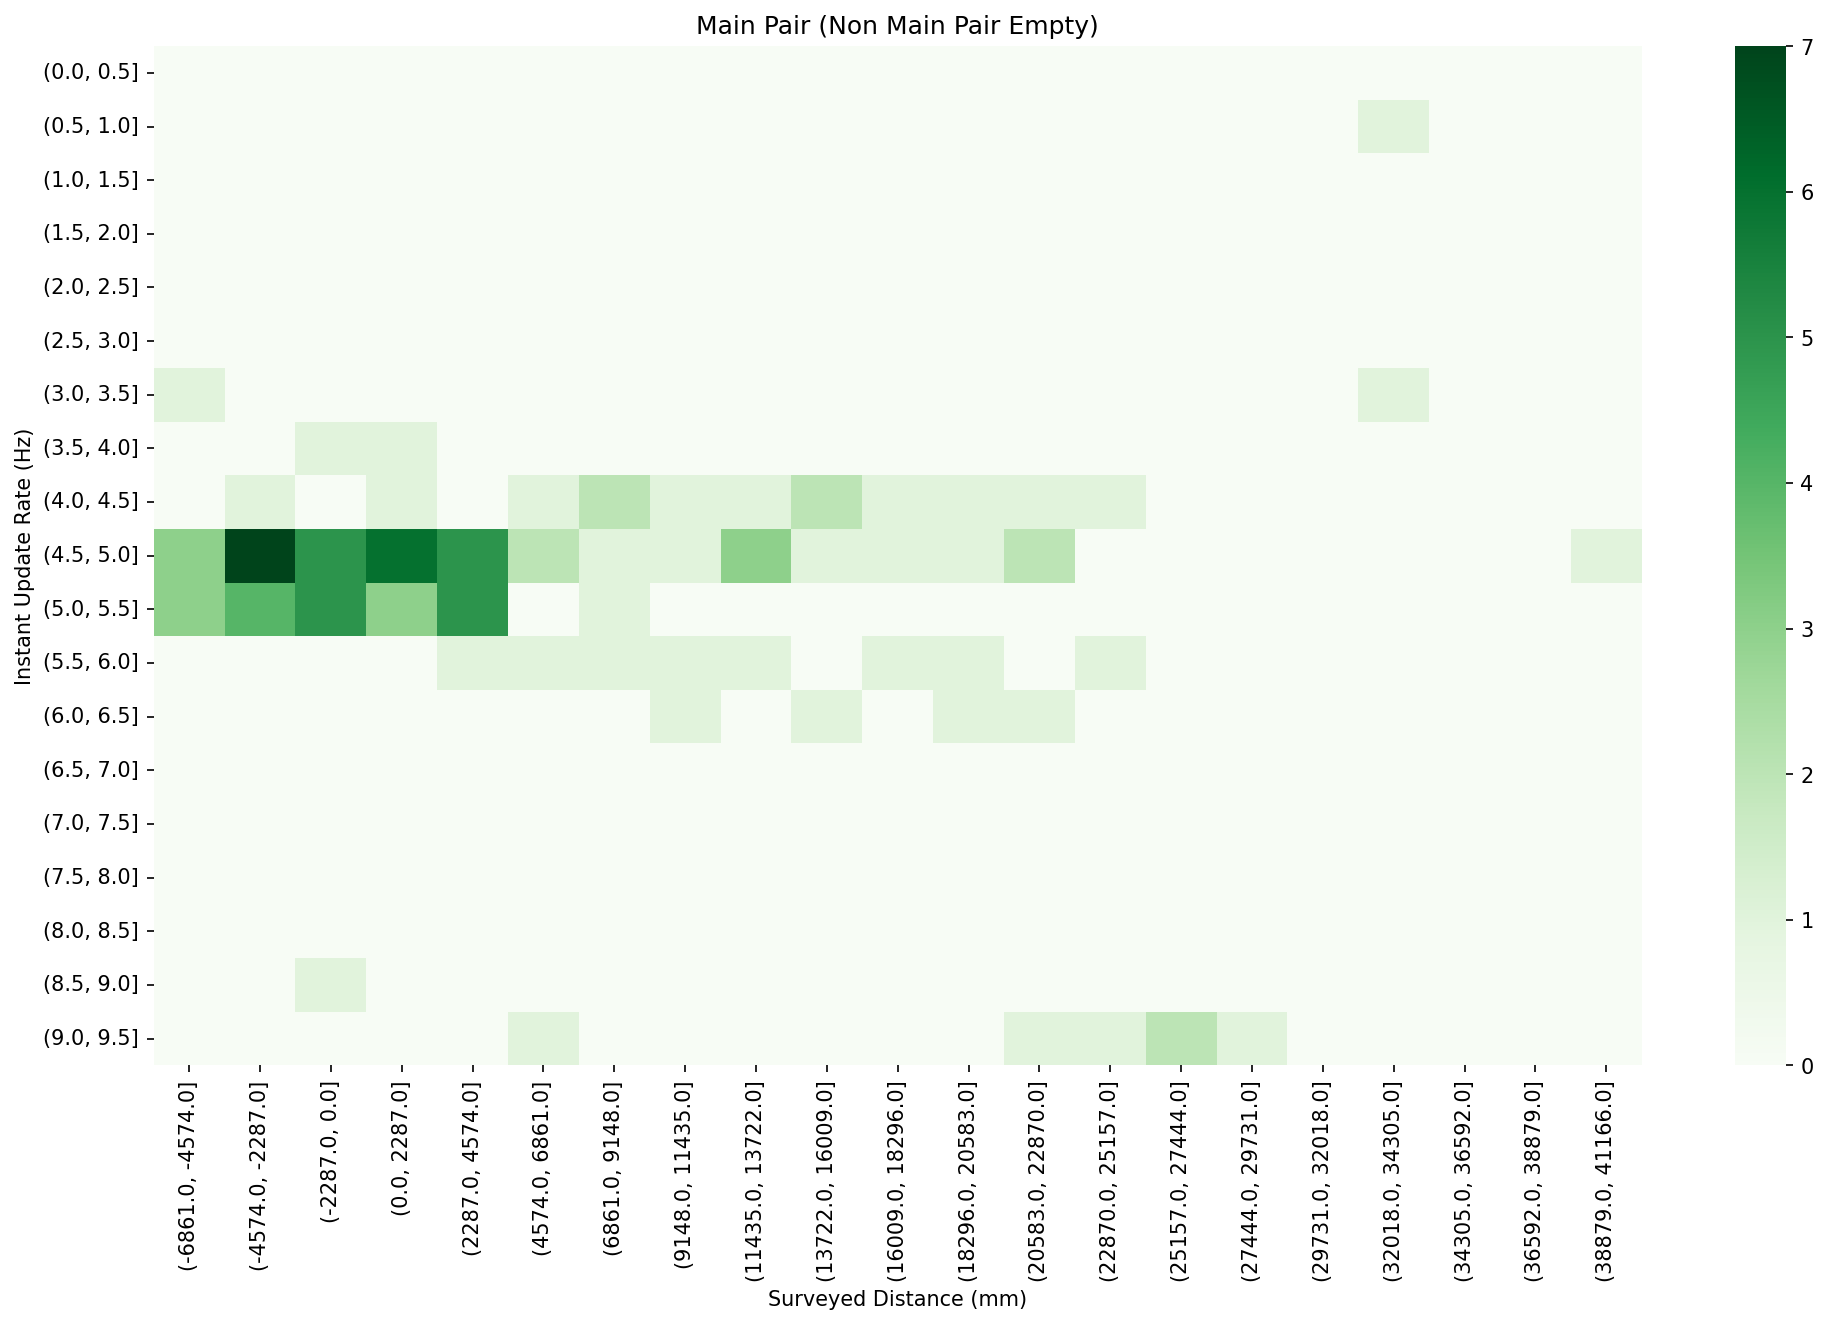

In [14]:
_static_veh_dist_notnull_main = static_veh_main_pair["Surveyed Distance (mm)"].dropna()
_static_veh_hz_notnull_main = static_veh_main_pair["Instant Update Rate (Hz)"].dropna()
_static_veh_dist_notnull_non_main = static_veh_non_main["Surveyed Distance (mm)"].dropna()
_static_veh_hz_notnull_non_main = static_veh_non_main["Instant Update Rate (Hz)"].dropna()
min_update_rate_regarded_as_normal = 9.9
bin_count = 20

dist_bin_main = round((max(_static_veh_dist_notnull_main) - min(_static_veh_dist_notnull_main)) / bin_count, 0)
hz_bin_main = round((min_update_rate_regarded_as_normal - min(_static_veh_hz_notnull_main)) / bin_count, 1)

dist_bin_non_main = round((max(_static_veh_dist_notnull_non_main) - min(_static_veh_dist_notnull_non_main)) / bin_count, 0)
hz_bin_non_main = max(round((min_update_rate_regarded_as_normal - min(_static_veh_hz_notnull_non_main)) / bin_count, 1), 0.1)

dist_bins_main = np.arange(dist_bin_main * (min(_static_veh_dist_notnull_main) // dist_bin_main), 
                           dist_bin_main * ((max(_static_veh_dist_notnull_main) + dist_bin_main) // dist_bin_main + 1), 
                           dist_bin_main)
hz_bins_main = np.arange(hz_bin_main * (min(_static_veh_hz_notnull_main) // hz_bin_main), 
                         hz_bin_main * ((max(_static_veh_hz_notnull_main) + hz_bin_main) // hz_bin_main + 1), 
                         hz_bin_main)

dist_bins_non_main = np.arange(dist_bin_non_main * (min(_static_veh_dist_notnull_non_main) // dist_bin_non_main), 
                               dist_bin_non_main * ((max(_static_veh_dist_notnull_non_main) + dist_bin_non_main) // dist_bin_non_main + 1), 
                               dist_bin_non_main)
hz_bins_non_main = np.arange(hz_bin_non_main * (min(_static_veh_hz_notnull_non_main) // hz_bin_non_main), 
                             hz_bin_non_main * ((max(_static_veh_hz_notnull_non_main) + hz_bin_non_main) // hz_bin_non_main + 1), 
                             hz_bin_non_main)

df_main_pair_assorted = pd.DataFrame(index=(static_veh_main_pair["Instant Update Rate (Hz)"]
                                            .dropna()
                                            .groupby(pd.cut(static_veh_main_pair["Instant Update Rate (Hz)"].dropna(), 
                                                            hz_bins_main))
                                            .count()
                                            .index),
                                     columns=(static_veh_main_pair["Surveyed Distance (mm)"]
                                              .dropna()
                                              .groupby(pd.cut(static_veh_main_pair["Surveyed Distance (mm)"].dropna(), 
                                                              dist_bins_main))
                                              .count()
                                              .index)
                                    ).replace(np.nan, 0)

df_non_main_assorted = pd.DataFrame(index=(static_veh_non_main["Instant Update Rate (Hz)"]
                                           .dropna()
                                           .groupby(pd.cut(static_veh_non_main["Instant Update Rate (Hz)"].dropna(), 
                                                           hz_bins_non_main))
                                           .count()
                                           .index),
                                    columns=(static_veh_non_main["Surveyed Distance (mm)"]
                                             .dropna()
                                             .groupby(pd.cut(static_veh_non_main["Surveyed Distance (mm)"].dropna(), 
                                                             dist_bins_non_main))
                                             .count()
                                             .index)
                                    ).replace(np.nan, 0)

for index, row in static_veh_main_pair.iterrows():
    if pd.isnull(row["Instant Update Rate (Hz)"]) or pd.isnull(row["Surveyed Distance (mm)"]):
        continue
    df_main_pair_assorted.iloc[
        df_main_pair_assorted.index.get_loc(row["Instant Update Rate (Hz)"]),
        df_main_pair_assorted.columns.get_loc(row["Surveyed Distance (mm)"])
    ] += 1
for index, row in static_veh_non_main.iterrows():
    if pd.isnull(row["Instant Update Rate (Hz)"]) or pd.isnull(row["Surveyed Distance (mm)"]):
        continue
    df_non_main_assorted.iloc[
        df_non_main_assorted.index.get_loc(row["Instant Update Rate (Hz)"]),
        df_non_main_assorted.columns.get_loc(row["Surveyed Distance (mm)"])
    ] += 1
figure = plt.figure(figsize=(16, 9), dpi=150)
if not df_non_main_assorted.loc[
    [i.right < min_update_rate_regarded_as_normal for i in df_non_main_assorted.index.array]].empty:
    ax1 = figure.add_subplot(121)
    h1 = sns.heatmap(df_main_pair_assorted.loc[
    [i.right < min_update_rate_regarded_as_normal for i in df_main_pair_assorted.index.array]],
                 cmap="Greens")

    ax1.set_title("Main Pair")
    ax2 = figure.add_subplot(122)
    h2 = sns.heatmap(df_non_main_assorted.loc[
        [i.right < min_update_rate_regarded_as_normal for i in df_non_main_assorted.index.array]],
                     cmap="Greens")
    ax2.set_title("Non Main Pair")
else:
    ax1 = figure.add_subplot(111)
    h1 = sns.heatmap(df_main_pair_assorted.loc[
    [i.right < min_update_rate_regarded_as_normal for i in df_main_pair_assorted.index.array]],
                 cmap="Greens")
    ax1.set_title("Main Pair (Non Main Pair Empty)")
plt.show()

### Moving Vehicle

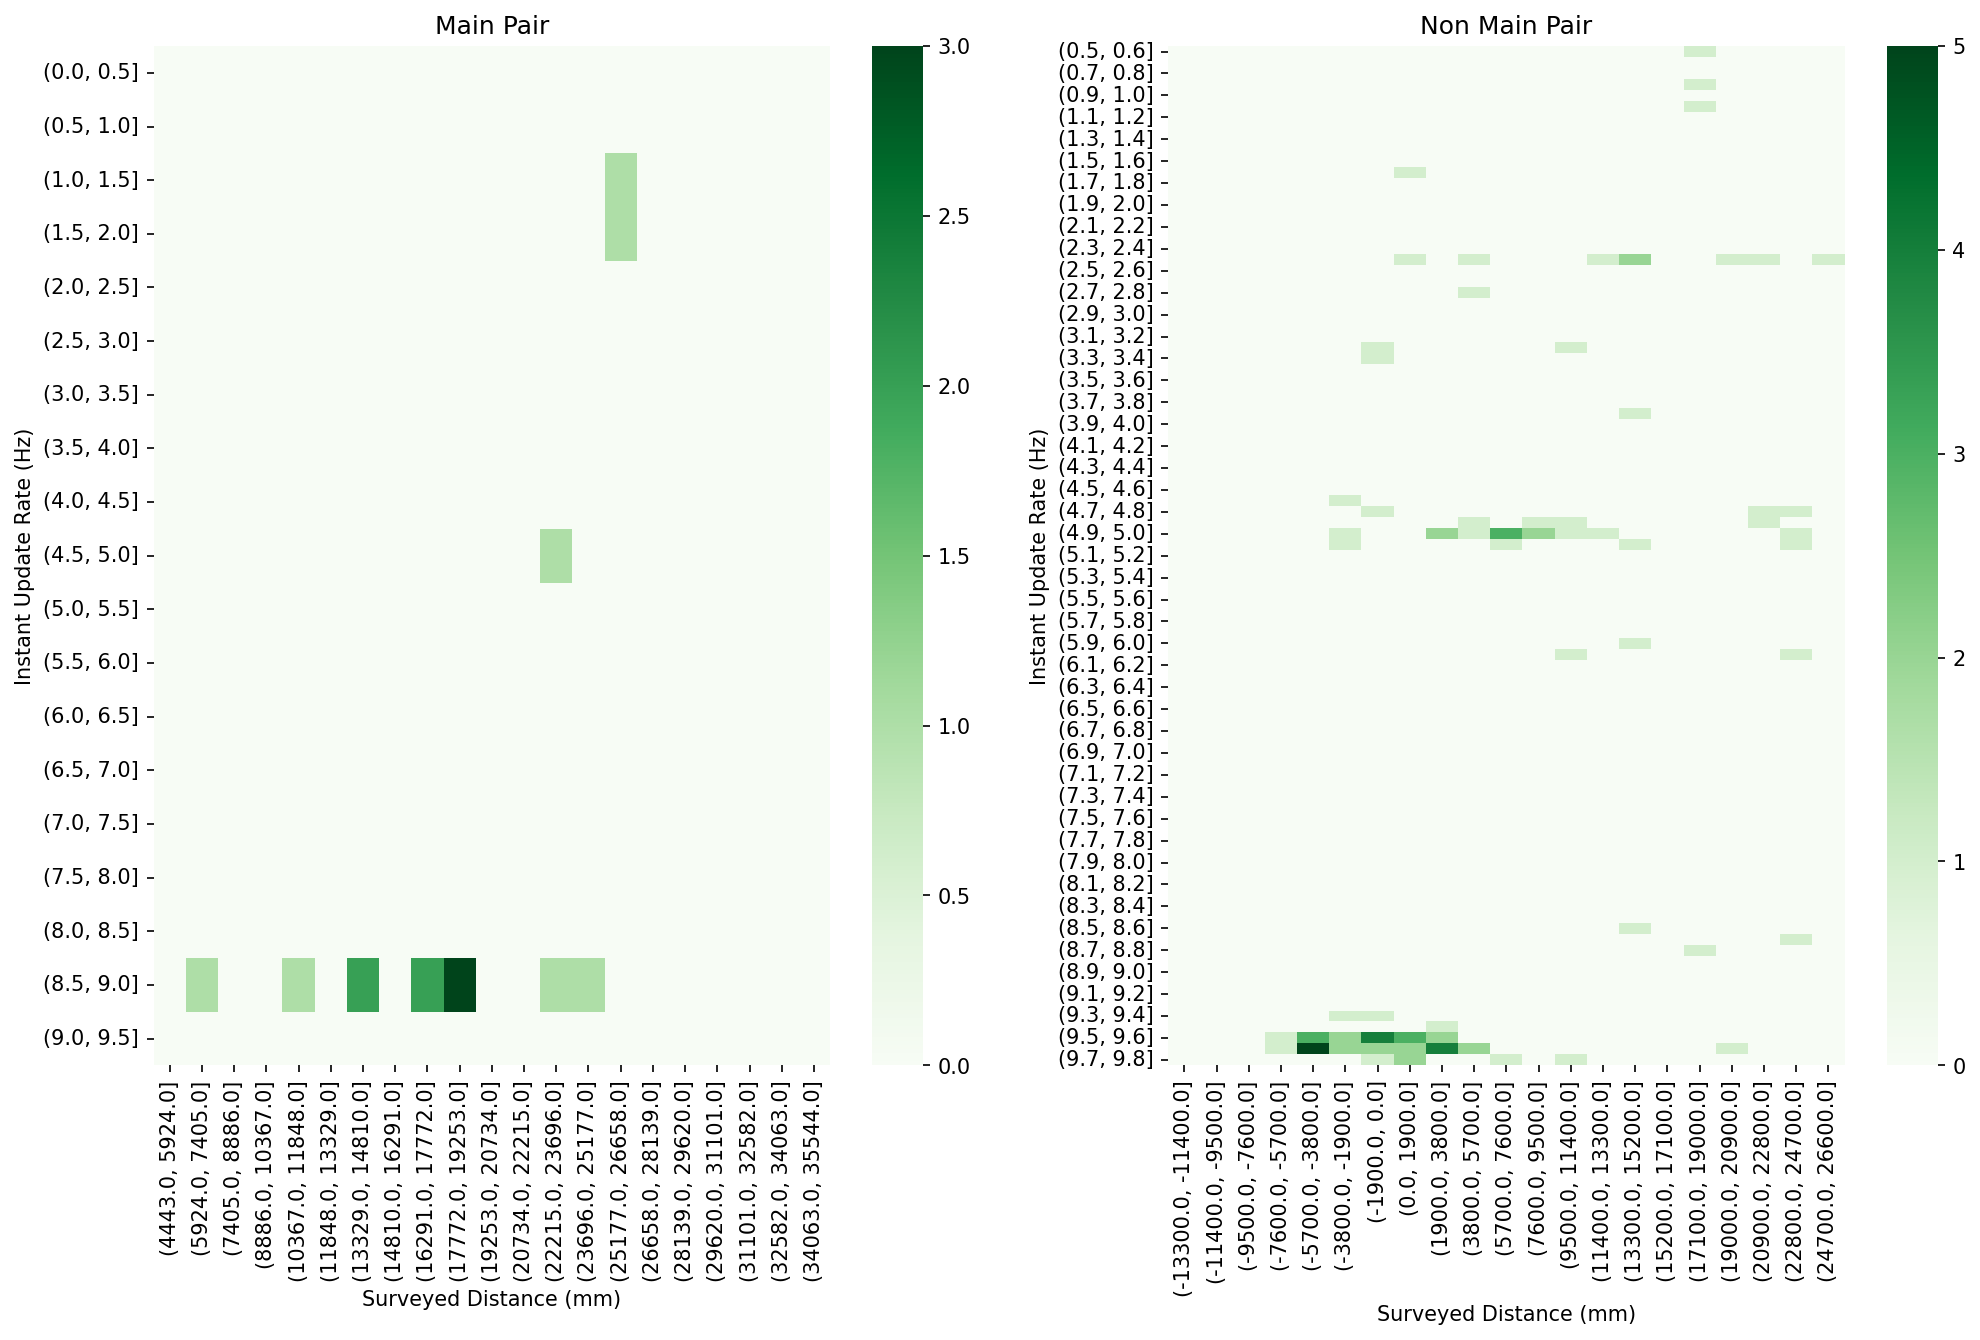

In [15]:
_moving_veh_dist_notnull_main = moving_veh_main_pair["Surveyed Distance (mm)"].dropna()
_moving_veh_hz_notnull_main = moving_veh_main_pair["Instant Update Rate (Hz)"].dropna()
_moving_veh_dist_notnull_non_main = moving_veh_non_main["Surveyed Distance (mm)"].dropna()
_moving_veh_hz_notnull_non_main = moving_veh_non_main["Instant Update Rate (Hz)"].dropna()
min_update_rate_regarded_as_normal = 9.9
bin_count = 20

dist_bin_main = round((max(_moving_veh_dist_notnull_main) - min(_moving_veh_dist_notnull_main)) / bin_count, 0)
hz_bin_main = round((min_update_rate_regarded_as_normal - min(_moving_veh_hz_notnull_main)) / bin_count, 1)

dist_bin_non_main = round((max(_moving_veh_dist_notnull_non_main) - min(_moving_veh_dist_notnull_non_main)) / bin_count, 0)
hz_bin_non_main = max(round((min_update_rate_regarded_as_normal - min(_static_veh_hz_notnull_non_main)) / bin_count, 1), 0.1)

dist_bins_main = np.arange(dist_bin_main * (min(_moving_veh_dist_notnull_main) // dist_bin_main), 
                           dist_bin_main * ((max(_moving_veh_dist_notnull_main) + dist_bin_main) // dist_bin_main + 1), 
                           dist_bin_main)
hz_bins_main = np.arange(hz_bin_main * (min(_moving_veh_hz_notnull_main) // hz_bin_main), 
                         hz_bin_main * ((max(_moving_veh_hz_notnull_main) + hz_bin_main) // hz_bin_main + 1), 
                         hz_bin_main)

dist_bins_non_main = np.arange(dist_bin_non_main * (min(_moving_veh_dist_notnull_non_main) // dist_bin_non_main), 
                               dist_bin_non_main * ((max(_moving_veh_dist_notnull_non_main) + dist_bin_non_main) // dist_bin_non_main + 1), 
                               dist_bin_non_main)
hz_bins_non_main = np.arange(hz_bin_non_main * (min(_moving_veh_hz_notnull_non_main) // hz_bin_non_main), 
                             hz_bin_non_main * ((max(_moving_veh_hz_notnull_non_main) + hz_bin_non_main) // hz_bin_non_main + 1), 
                             hz_bin_non_main)

df_main_pair_assorted = pd.DataFrame(index=(moving_veh_main_pair["Instant Update Rate (Hz)"]
                                            .dropna()
                                            .groupby(pd.cut(moving_veh_main_pair["Instant Update Rate (Hz)"].dropna(), 
                                                            hz_bins_main))
                                            .count()
                                            .index),
                                     columns=(moving_veh_main_pair["Surveyed Distance (mm)"]
                                              .dropna()
                                              .groupby(pd.cut(moving_veh_main_pair["Surveyed Distance (mm)"].dropna(), 
                                                              dist_bins_main))
                                              .count()
                                              .index)
                                    ).replace(np.nan, 0)

df_non_main_assorted = pd.DataFrame(index=(moving_veh_non_main["Instant Update Rate (Hz)"]
                                           .dropna()
                                           .groupby(pd.cut(moving_veh_non_main["Instant Update Rate (Hz)"].dropna(), 
                                                           hz_bins_non_main))
                                           .count()
                                           .index),
                                    columns=(moving_veh_non_main["Surveyed Distance (mm)"]
                                             .dropna()
                                             .groupby(pd.cut(moving_veh_non_main["Surveyed Distance (mm)"].dropna(), 
                                                             dist_bins_non_main))
                                             .count()
                                             .index)
                                    ).replace(np.nan, 0)

for index, row in moving_veh_main_pair.iterrows():
    if pd.isnull(row["Instant Update Rate (Hz)"]) or pd.isnull(row["Surveyed Distance (mm)"]):
        continue
    df_main_pair_assorted.iloc[
        df_main_pair_assorted.index.get_loc(row["Instant Update Rate (Hz)"]),
        df_main_pair_assorted.columns.get_loc(row["Surveyed Distance (mm)"])
    ] += 1
for index, row in moving_veh_non_main.iterrows():
    if pd.isnull(row["Instant Update Rate (Hz)"]) or pd.isnull(row["Surveyed Distance (mm)"]):
        continue
    df_non_main_assorted.iloc[
        df_non_main_assorted.index.get_loc(row["Instant Update Rate (Hz)"]),
        df_non_main_assorted.columns.get_loc(row["Surveyed Distance (mm)"])
    ] += 1
figure = plt.figure(figsize=(16, 9), dpi=150)
if not df_non_main_assorted.loc[
    [i.right < min_update_rate_regarded_as_normal for i in df_non_main_assorted.index.array]].empty:
    ax1 = figure.add_subplot(121)
    h1 = sns.heatmap(df_main_pair_assorted.loc[
    [i.right < min_update_rate_regarded_as_normal for i in df_main_pair_assorted.index.array]],
                 cmap="Greens")

    ax1.set_title("Main Pair")
    ax2 = figure.add_subplot(122)
    h2 = sns.heatmap(df_non_main_assorted.loc[
        [i.right < min_update_rate_regarded_as_normal for i in df_non_main_assorted.index.array]],
                     cmap="Greens")
    ax2.set_title("Non Main Pair")
else:
    ax1 = figure.add_subplot(111)
    h1 = sns.heatmap(df_main_pair_assorted.loc[
    [i.right < min_update_rate_regarded_as_normal for i in df_main_pair_assorted.index.array]],
                 cmap="Greens")
    ax1.set_title("Main Pair (Non Main Pair Empty)")
plt.show()

## Normalized Update Rate v.s. Relative/Absolute Relative Speed, Aggregated Pairs

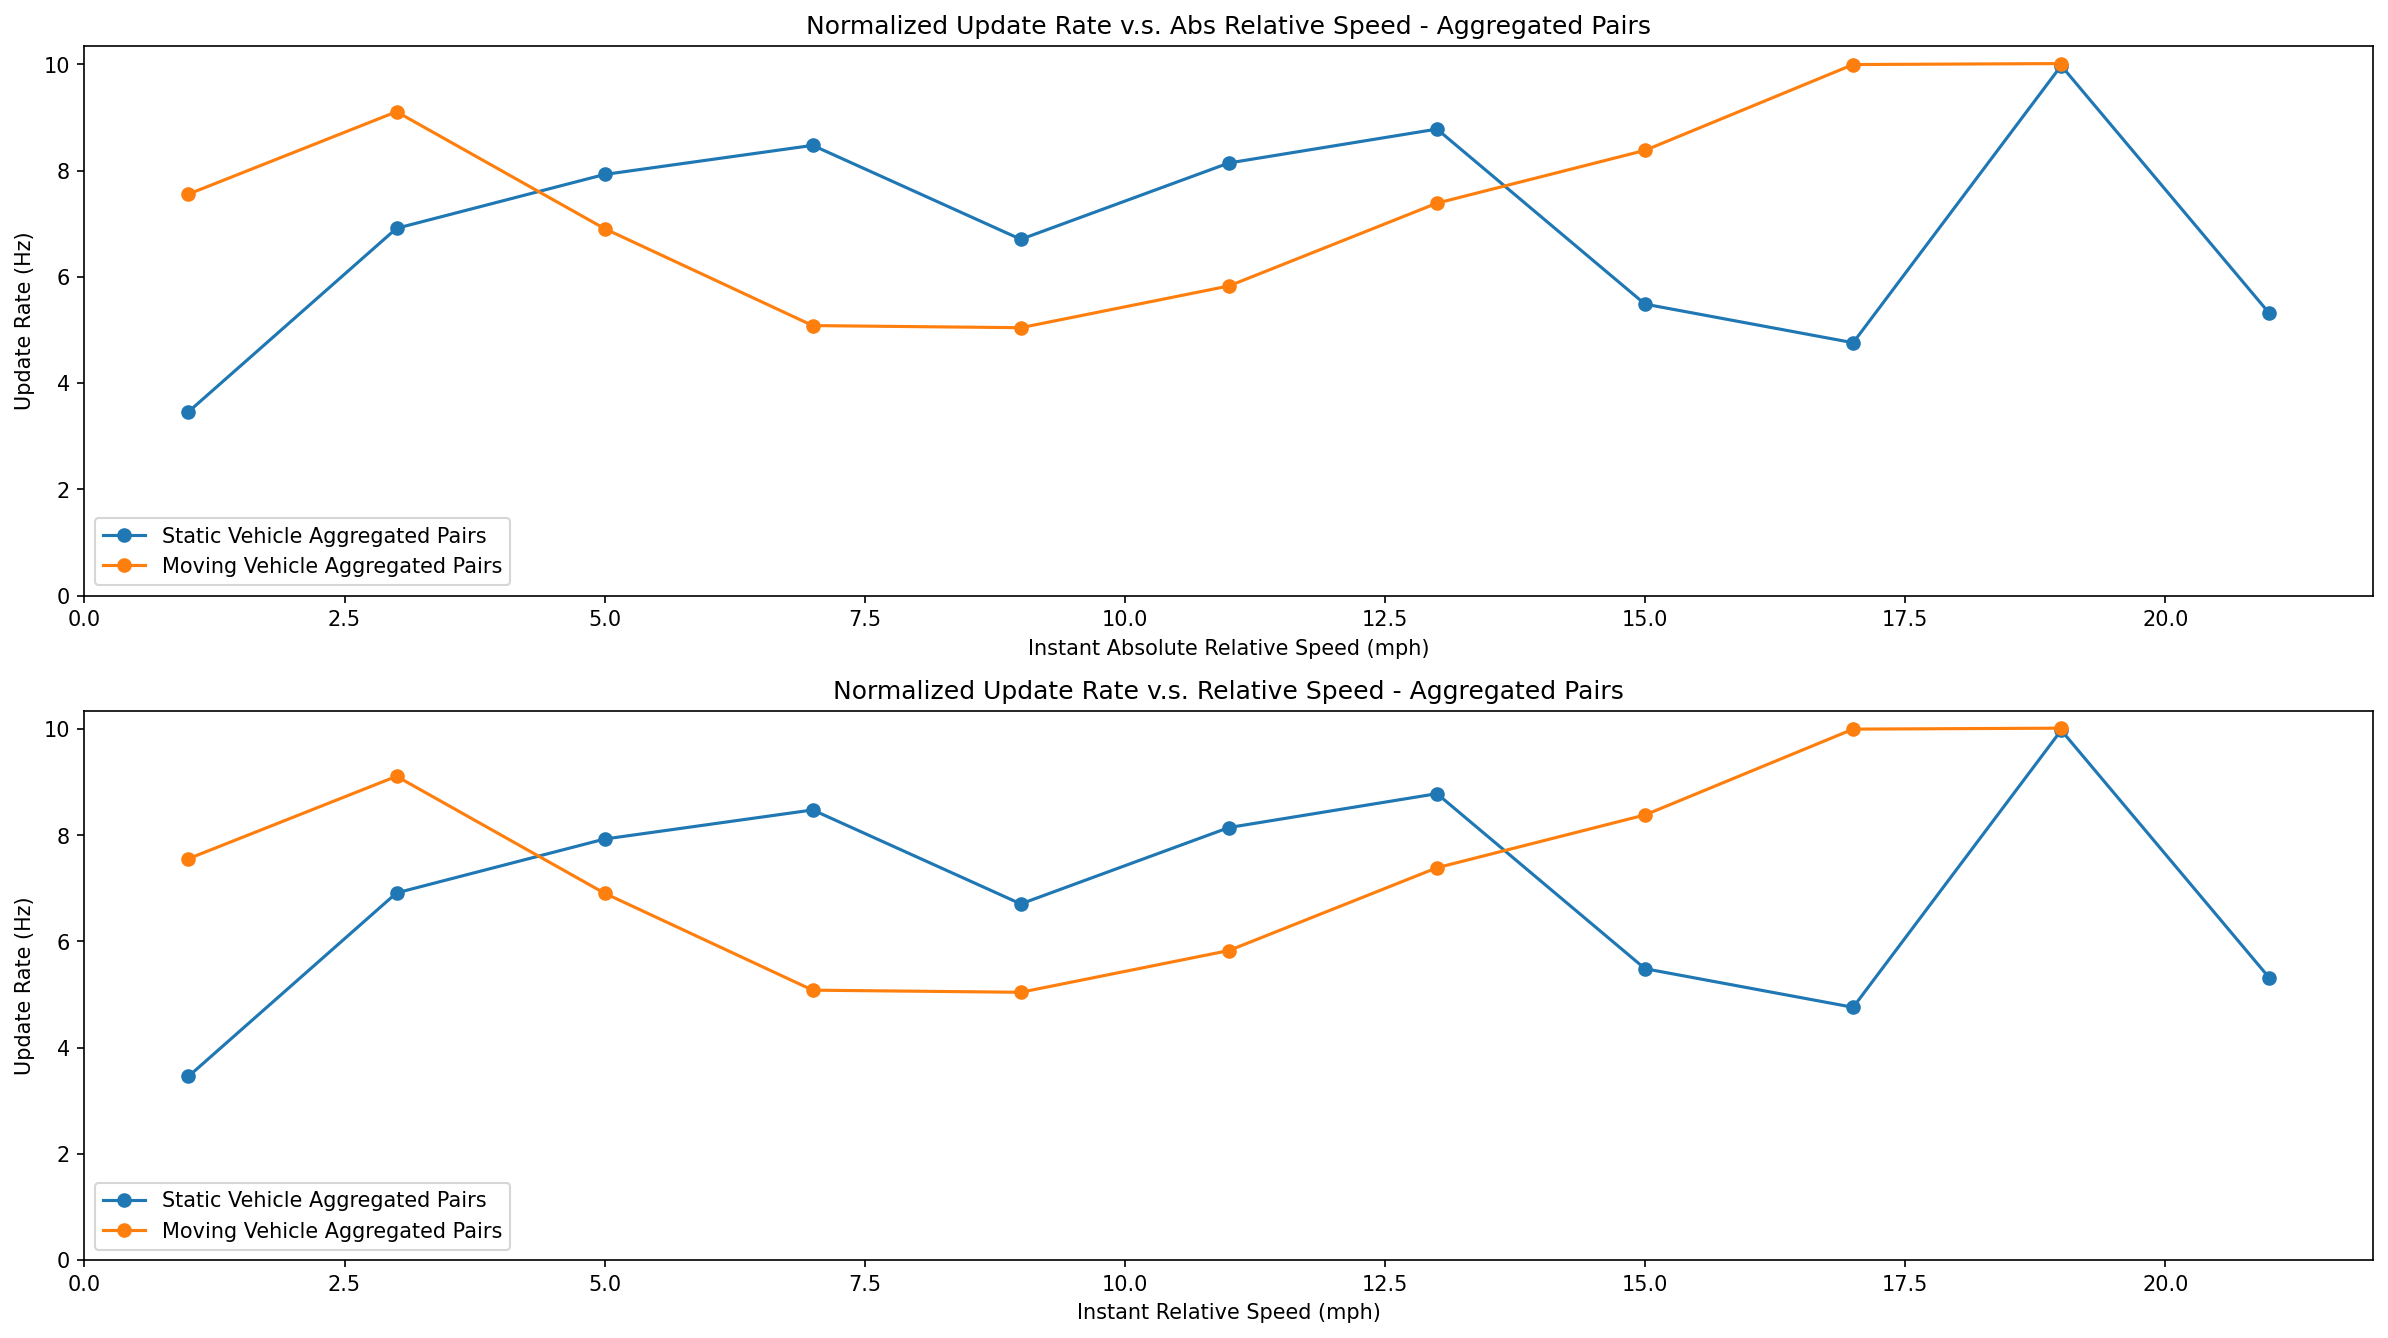

In [16]:
v_bin = 2
v_range = [-30, 30]

static_grouped_list_veh_idx = []
categorical_idx_static = None
for df in static_stats_time_idx:
    df = df[df["Surveyed Distance (mm)"].notnull()]
    if df.shape[0] == 0:
        continue
    else: 
        assert df["Surveyed Distance (mm)"].dropna().is_monotonic_increasing \
            or df["Surveyed Distance (mm)"].dropna().is_monotonic_decreasing
        for master, slave_list in static_master_slave_mapping.items():
            for slave in slave_list:
                pairwise_df = df[(df["Initiating Master"] == master) & (df["Reporting Slave"] == slave)]
                if pairwise_df.index.empty:
                    continue
                pairwise_df = pairwise_df.set_index("Instant Speed by Marker (mph)")
                pairwise_df["Time Interval (s)"] = pairwise_df["Timestamp Norm (s)"].diff()
                pairwise_df = pairwise_df[(pairwise_df.index.notnull()) & (np.isfinite(pairwise_df.index))]
                if pairwise_df.index.empty:
                    continue
                bins = np.arange(v_bin * (min(pairwise_df.index) // v_bin), 
                                 v_bin * ((max(pairwise_df.index) + v_bin) // v_bin + 1), 
                                 v_bin)
                grouped_df = pd.DataFrame()
                grouped_df["duration"] = pairwise_df["Time Interval (s)"].groupby(pd.cut(pairwise_df.index, bins)).sum()
                grouped_df["reporting counts"] = pairwise_df["Timestamp Norm (s)"].groupby(
                    pd.cut(pairwise_df.index, bins)).count()
                grouped_df["Is Main Pair"] = (master == static_main_master) & \
                    (slave == static_master_slave_mapping[static_main_master][0])
                static_grouped_list_veh_idx.append(grouped_df)
                if categorical_idx_static is None:
                    categorical_idx_static = grouped_df.index
                else:
                    categorical_idx_static = categorical_idx_static.union(grouped_df.index)
                
static_df_counts_spd_idx = pd.DataFrame(index=categorical_idx_static, columns=['reporting counts', 'duration'])
static_df_counts_spd_idx['reporting counts'] = 0
static_df_counts_spd_idx['duration'] = 0
for df in static_grouped_list_veh_idx:
    df = df.reindex_like(static_df_counts_spd_idx).fillna(0)
    static_df_counts_spd_idx['reporting counts'] = static_df_counts_spd_idx['reporting counts'] + df['reporting counts']
    static_df_counts_spd_idx['duration'] = static_df_counts_spd_idx['duration'] + df['duration']
static_df_idx_min = static_df_counts_spd_idx.loc[static_df_counts_spd_idx["reporting counts"] >= 2].index.min()
static_df_idx_max = static_df_counts_spd_idx.loc[static_df_counts_spd_idx["reporting counts"] >= 2].index.max()
static_df_filtered = static_df_counts_spd_idx.loc[static_df_idx_min:static_df_idx_max]
    
moving_grouped_list_veh_idx = []
categorical_idx_moving = None
for df in moving_stats_time_idx:
    df = df[df["Surveyed Distance (mm)"].notnull()]
    if df.shape[0] == 0:
        continue
    else: 
        assert df["Surveyed Distance (mm)"].dropna().is_monotonic_increasing \
            or df["Surveyed Distance (mm)"].dropna().is_monotonic_decreasing
        for master, slave_list in moving_master_slave_mapping.items():
            for slave in slave_list:
                pairwise_df = df[(df["Initiating Master"] == master) & (df["Reporting Slave"] == slave)]
                if df.index.empty:
                    continue
                pairwise_df = pairwise_df.set_index("Instant Speed by Marker (mph)")
                pairwise_df["Time Interval (s)"] = pairwise_df["Timestamp Norm (s)"].diff()
                pairwise_df = pairwise_df[(pairwise_df.index.notnull()) & (np.isfinite(pairwise_df.index))]
                if pairwise_df.index.empty:
                    continue
                bins = np.arange(v_bin * (min(pairwise_df.index) // v_bin), 
                                 v_bin * ((max(pairwise_df.index) + v_bin) // v_bin + 1), 
                                 v_bin)
                grouped_df = pd.DataFrame()
                grouped_df["duration"] = pairwise_df["Time Interval (s)"].groupby(pd.cut(pairwise_df.index, bins)).sum()
                grouped_df["reporting counts"] = pairwise_df["Timestamp Norm (s)"].groupby(
                    pd.cut(pairwise_df.index, bins)).count()
                grouped_df["Is Main Pair"] = (master == moving_main_master) & \
                    (slave == moving_master_slave_mapping[moving_main_master][0])
                moving_grouped_list_veh_idx.append(grouped_df)
                if categorical_idx_moving is None:
                    categorical_idx_moving = grouped_df.index
                else:
                    categorical_idx_moving = categorical_idx_moving.union(grouped_df.index)
                
moving_df_counts_spd_idx = pd.DataFrame(index=categorical_idx_moving, columns=['reporting counts', 'duration'])
moving_df_counts_spd_idx['reporting counts'] = 0
moving_df_counts_spd_idx['duration'] = 0
for df in moving_grouped_list_veh_idx:
    df = df.reindex_like(moving_df_counts_spd_idx).fillna(0)
    moving_df_counts_spd_idx['reporting counts'] = moving_df_counts_spd_idx['reporting counts'] + df['reporting counts']
    moving_df_counts_spd_idx['duration'] = moving_df_counts_spd_idx['duration'] + df['duration']
moving_df_idx_min = moving_df_counts_spd_idx.loc[moving_df_counts_spd_idx["reporting counts"] >= 2].index.min()
moving_df_idx_max = moving_df_counts_spd_idx.loc[moving_df_counts_spd_idx["reporting counts"] >= 2].index.max()
moving_df_filtered = moving_df_counts_spd_idx.loc[moving_df_idx_min:moving_df_idx_max]

# Plotting - Relative Abs Speed 
static_df_filtered['absmid'] = [abs(i.mid) for i in static_df_filtered.index.array]
_temp_df_static = static_df_filtered.reset_index(drop=True)
bins = np.arange(0, 
                 v_bin * ((max(_temp_df_static['absmid']) + v_bin) // v_bin + 1), 
                 v_bin)
static_df_filtered_abs_spd = pd.DataFrame()
static_df_filtered_abs_spd["reporting counts"] = _temp_df_static.groupby(
    pd.cut(_temp_df_static['absmid'], bins)).apply(lambda i:sum(i["reporting counts"]))
static_df_filtered_abs_spd["duration"] = _temp_df_static.groupby(
    pd.cut(_temp_df_static['absmid'], bins)).apply(lambda i:sum(i["duration"]))

moving_df_filtered['absmid'] = [abs(i.mid) for i in moving_df_filtered.index.array]
_temp_df_moving = moving_df_filtered.reset_index(drop=True)
bins = np.arange(0, 
                 v_bin * ((max(_temp_df_static['absmid']) + v_bin) // v_bin + 1), 
                 v_bin)
moving_df_filtered_abs_spd = pd.DataFrame()
moving_df_filtered_abs_spd["reporting counts"] = _temp_df_moving.groupby(
    pd.cut(_temp_df_moving['absmid'], bins)).apply(lambda i:sum(i["reporting counts"]))
moving_df_filtered_abs_spd["duration"] = _temp_df_moving.groupby(
    pd.cut(_temp_df_moving['absmid'], bins)).apply(lambda i:sum(i["duration"]))

static_df_filtered_abs_spd = static_df_filtered_abs_spd.loc[
    [v_range[0] < i.mid < v_range[1] for i in static_df_filtered_abs_spd.index.array]]
moving_df_filtered_abs_spd = moving_df_filtered_abs_spd.loc[
    [v_range[0] < i.mid < v_range[1] for i in moving_df_filtered_abs_spd.index.array]]

static_df_filtered_signed_spd = static_df_filtered.loc[
    [v_range[0] < i.mid < v_range[1] for i in static_df_filtered.index.array]]
moving_df_filtered_signed_spd = moving_df_filtered.loc[
    [v_range[0] < i.mid < v_range[1] for i in moving_df_filtered.index.array]]

figure = plt.figure(figsize=(16, 9), dpi=150)
ax1 = figure.add_subplot(211)
ax1.plot([i.mid for i in (static_df_filtered_abs_spd['reporting counts'] / static_df_filtered_abs_spd['duration']).index.array], 
        static_df_filtered_abs_spd['reporting counts'] / static_df_filtered_abs_spd['duration'],
        label="Static Vehicle Aggregated Pairs", marker="o", color="C0")
ax1.plot([i.mid for i in (moving_df_filtered_abs_spd['reporting counts'] / moving_df_filtered_abs_spd['duration']).index.array], 
        moving_df_filtered_abs_spd['reporting counts'] / moving_df_filtered_abs_spd['duration'],
        label="Moving Vehicle Aggregated Pairs", marker="o", color="C1")
ax1.legend()
ax1.set_ylabel("Update Rate (Hz)")
ax1.set_xlabel("Instant Absolute Relative Speed (mph)")
ax1.set_title("Normalized Update Rate v.s. Abs Relative Speed - Aggregated Pairs")
ax1.set_ylim(bottom=0)

ax2 = figure.add_subplot(212)
ax2.plot([i.mid for i in 
          (static_df_filtered_signed_spd['reporting counts'] / static_df_filtered_signed_spd['duration']).index.array], 
         static_df_filtered_signed_spd['reporting counts'] / static_df_filtered_signed_spd['duration'],
         label="Static Vehicle Aggregated Pairs", marker="o", color="C0")
ax2.plot([i.mid for i in 
          (moving_df_filtered_signed_spd['reporting counts'] / moving_df_filtered_signed_spd['duration']).index.array], 
         moving_df_filtered_signed_spd['reporting counts'] / moving_df_filtered_signed_spd['duration'],
         label="Moving Vehicle Aggregated Pairs", marker="o", color="C1")
ax2.legend()
ax2.set_ylabel("Update Rate (Hz)")
ax2.set_xlabel("Instant Relative Speed (mph)")
ax2.set_title("Normalized Update Rate v.s. Relative Speed - Aggregated Pairs")
ax2.set_ylim(bottom=0)

figure.tight_layout(pad=1.0)
plt.show()

## Normalized Update Rate v.s. Relative/Absolute Relative Speed, Main Pair

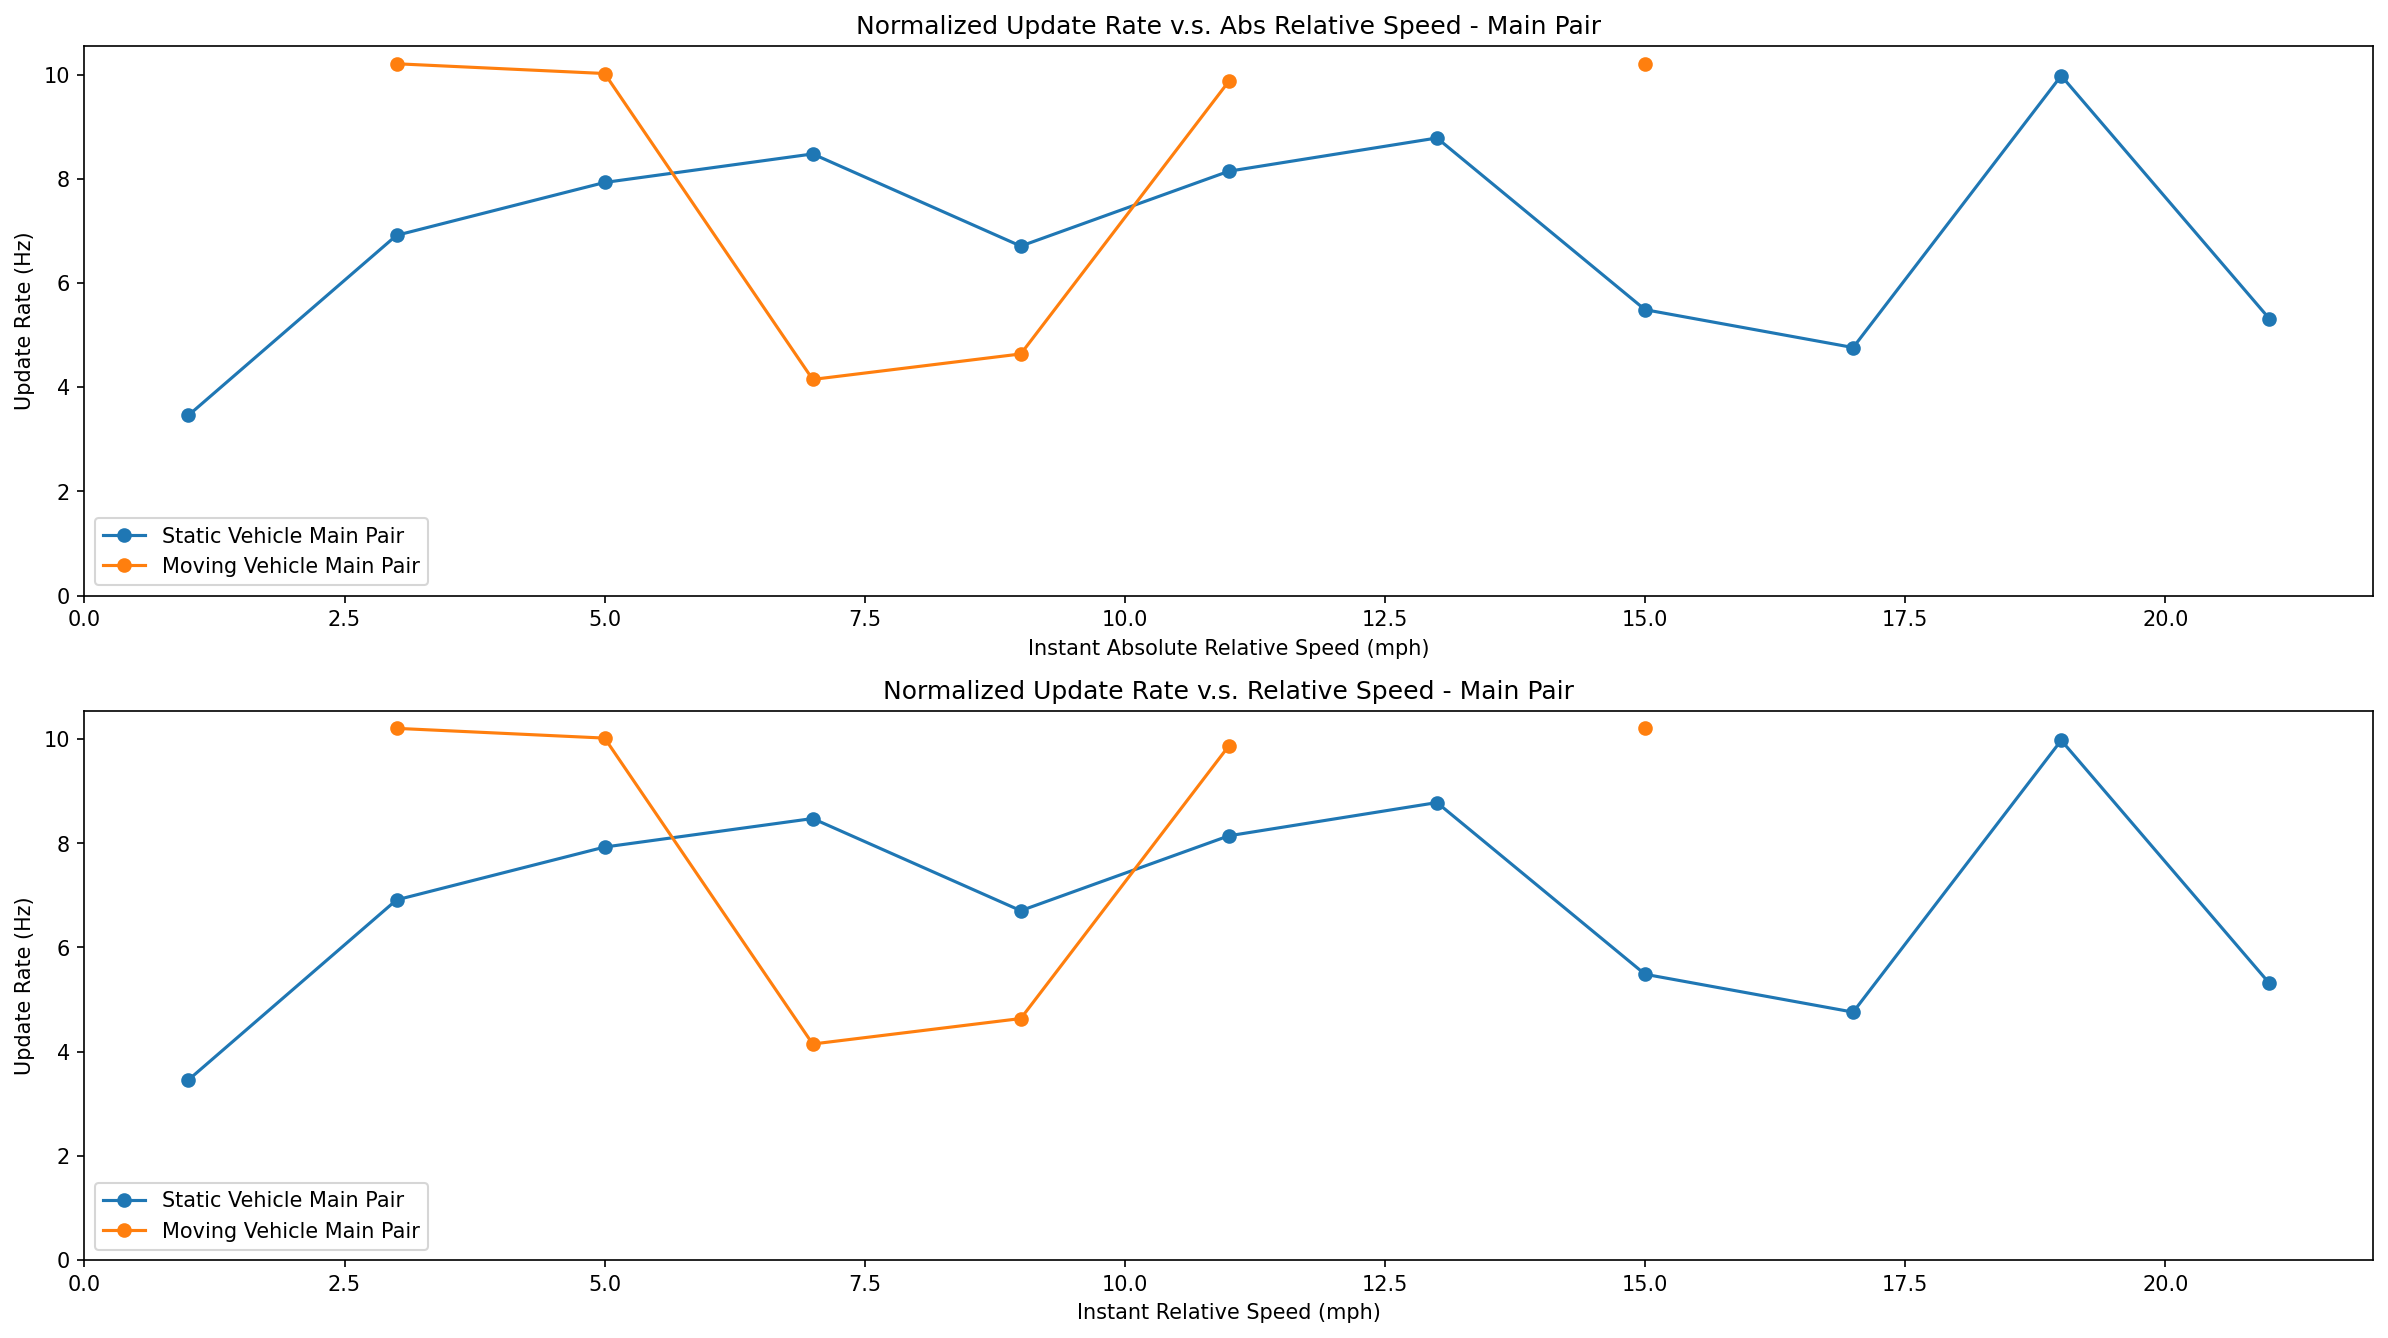

In [17]:
static_grouped_list_veh_idx_main_pair = []
categorical_idx_static_main_pair = None
for df in static_stats_time_idx:
    df = df[df["Surveyed Distance (mm)"].notnull()]
    if df.shape[0] == 0:
        continue
    else: 
        assert df["Surveyed Distance (mm)"].dropna().is_monotonic_increasing \
            or df["Surveyed Distance (mm)"].dropna().is_monotonic_decreasing
        # Main Pair
        mainpair_df = df[(df["Initiating Master"] == static_main_master) & (df["Reporting Slave"] == static_focusing_slaves[0])]
        if mainpair_df.index.empty:
            continue
        mainpair_df = mainpair_df.set_index("Instant Speed by Marker (mph)")
        mainpair_df["Time Interval (s)"] = mainpair_df["Timestamp Norm (s)"].diff()
        mainpair_df = mainpair_df[(mainpair_df.index.notnull()) & (np.isfinite(mainpair_df.index))]
        if mainpair_df.index.empty:
            continue
        bins = np.arange(v_bin * (min(mainpair_df.index) // v_bin), 
                         v_bin * ((max(mainpair_df.index) + v_bin) // v_bin + 1), 
                         v_bin)
        grouped_df = pd.DataFrame()
        grouped_df["duration"] = mainpair_df["Time Interval (s)"].groupby(pd.cut(mainpair_df.index, bins)).sum()
        grouped_df["reporting counts"] = mainpair_df["Timestamp Norm (s)"].groupby(
            pd.cut(mainpair_df.index, bins)).count()
        grouped_df["Is Main Pair"] = (master == static_main_master) & \
            (slave == static_master_slave_mapping[static_main_master][0])
        static_grouped_list_veh_idx_main_pair.append(grouped_df)
        if categorical_idx_static_main_pair is None:
            categorical_idx_static_main_pair = grouped_df.index
        else:
            categorical_idx_static_main_pair = categorical_idx_static_main_pair.union(grouped_df.index)
                
static_df_counts_spd_idx_main_pair = pd.DataFrame(index=categorical_idx_static_main_pair, columns=['reporting counts', 'duration'])
static_df_counts_spd_idx_main_pair['reporting counts'] = 0
static_df_counts_spd_idx_main_pair['duration'] = 0
for df in static_grouped_list_veh_idx_main_pair:
    df = df.reindex_like(static_df_counts_spd_idx_main_pair).fillna(0)
    static_df_counts_spd_idx_main_pair['reporting counts'] = static_df_counts_spd_idx_main_pair['reporting counts'] + df['reporting counts']
    static_df_counts_spd_idx_main_pair['duration'] = static_df_counts_spd_idx_main_pair['duration'] + df['duration']
static_df_idx_min = static_df_counts_spd_idx_main_pair.loc[static_df_counts_spd_idx_main_pair["reporting counts"] >= 2].index.min()
static_df_idx_max = static_df_counts_spd_idx_main_pair.loc[static_df_counts_spd_idx_main_pair["reporting counts"] >= 2].index.max()
static_df_filtered_main_pair = static_df_counts_spd_idx_main_pair.loc[static_df_idx_min:static_df_idx_max]
    
moving_grouped_list_veh_idx_main_pair = []
categorical_idx_moving_main_pair = None
for df in moving_stats_time_idx:
    df = df[df["Surveyed Distance (mm)"].notnull()]
    if df.shape[0] == 0:
        continue
    else: 
        assert df["Surveyed Distance (mm)"].dropna().is_monotonic_increasing \
            or df["Surveyed Distance (mm)"].dropna().is_monotonic_decreasing
        # Main Pair
        mainpair_df = df[(df["Initiating Master"] == moving_main_master) & (df["Reporting Slave"] == moving_focusing_slaves[0])]
        if df.index.empty:
            continue
        mainpair_df = mainpair_df.set_index("Instant Speed by Marker (mph)")
        mainpair_df["Time Interval (s)"] = mainpair_df["Timestamp Norm (s)"].diff()
        mainpair_df = mainpair_df[(mainpair_df.index.notnull()) & (np.isfinite(mainpair_df.index))]
        if mainpair_df.index.empty:
            continue
        bins = np.arange(v_bin * (min(mainpair_df.index) // v_bin), 
                         v_bin * ((max(mainpair_df.index) + v_bin) // v_bin + 1), 
                         v_bin)
        grouped_df = pd.DataFrame()
        grouped_df["duration"] = mainpair_df["Time Interval (s)"].groupby(pd.cut(mainpair_df.index, bins)).sum()
        grouped_df["reporting counts"] = mainpair_df["Timestamp Norm (s)"].groupby(
            pd.cut(mainpair_df.index, bins)).count()
        grouped_df["Is Main Pair"] = (master == moving_main_master) & \
            (slave == moving_master_slave_mapping[moving_main_master][0])
        moving_grouped_list_veh_idx_main_pair.append(grouped_df)
        if categorical_idx_moving_main_pair is None:
            categorical_idx_moving_main_pair = grouped_df.index
        else:
            categorical_idx_moving_main_pair = categorical_idx_moving_main_pair.union(grouped_df.index)
                
moving_df_counts_spd_idx_main_pair = pd.DataFrame(index=categorical_idx_moving_main_pair, columns=['reporting counts', 'duration'])
moving_df_counts_spd_idx_main_pair['reporting counts'] = 0
moving_df_counts_spd_idx_main_pair['duration'] = 0
for df in moving_grouped_list_veh_idx_main_pair:
    df = df.reindex_like(moving_df_counts_spd_idx_main_pair).fillna(0)
    moving_df_counts_spd_idx_main_pair['reporting counts'] = moving_df_counts_spd_idx_main_pair['reporting counts'] + df['reporting counts']
    moving_df_counts_spd_idx_main_pair['duration'] = moving_df_counts_spd_idx_main_pair['duration'] + df['duration']
moving_df_idx_min = moving_df_counts_spd_idx_main_pair.loc[moving_df_counts_spd_idx_main_pair["reporting counts"] >= 2].index.min()
moving_df_idx_max = moving_df_counts_spd_idx_main_pair.loc[moving_df_counts_spd_idx_main_pair["reporting counts"] >= 2].index.max()
moving_df_filtered_main_pair = moving_df_counts_spd_idx_main_pair.loc[moving_df_idx_min:moving_df_idx_max]

# Plotting - Relative Abs Speed 
static_df_filtered_main_pair['absmid'] = [abs(i.mid) for i in static_df_filtered_main_pair.index.array]
_temp_df_static = static_df_filtered_main_pair.reset_index(drop=True)
bins = np.arange(0, 
                 v_bin * ((max(_temp_df_static['absmid']) + v_bin) // v_bin + 1), 
                 v_bin)
static_df_filtered_main_pair_abs_spd = pd.DataFrame()
static_df_filtered_main_pair_abs_spd["reporting counts"] = _temp_df_static.groupby(
    pd.cut(_temp_df_static['absmid'], bins)).apply(lambda i:sum(i["reporting counts"]))
static_df_filtered_main_pair_abs_spd["duration"] = _temp_df_static.groupby(
    pd.cut(_temp_df_static['absmid'], bins)).apply(lambda i:sum(i["duration"]))

moving_df_filtered_main_pair['absmid'] = [abs(i.mid) for i in moving_df_filtered_main_pair.index.array]
_temp_df_moving = moving_df_filtered_main_pair.reset_index(drop=True)
bins = np.arange(0, 
                 v_bin * ((max(_temp_df_static['absmid']) + v_bin) // v_bin + 1), 
                 v_bin)
moving_df_filtered_main_pair_abs_spd = pd.DataFrame()
moving_df_filtered_main_pair_abs_spd["reporting counts"] = _temp_df_moving.groupby(
    pd.cut(_temp_df_moving['absmid'], bins)).apply(lambda i:sum(i["reporting counts"]))
moving_df_filtered_main_pair_abs_spd["duration"] = _temp_df_moving.groupby(
    pd.cut(_temp_df_moving['absmid'], bins)).apply(lambda i:sum(i["duration"]))

static_df_filtered_main_pair_abs_spd = static_df_filtered_main_pair_abs_spd.loc[
    [v_range[0] < i.mid < v_range[1] for i in static_df_filtered_main_pair_abs_spd.index.array]]
moving_df_filtered_main_pair_abs_spd = moving_df_filtered_main_pair_abs_spd.loc[
    [v_range[0] < i.mid < v_range[1] for i in moving_df_filtered_main_pair_abs_spd.index.array]]

# Plotting - Relative Signed Speed 
static_df_filtered_main_pair_signed_spd = static_df_filtered_main_pair.loc[
    [v_range[0] < i.mid < v_range[1] for i in static_df_filtered_main_pair.index.array]]
moving_df_filtered_main_pair_signed_spd = moving_df_filtered_main_pair.loc[
    [v_range[0] < i.mid < v_range[1] for i in moving_df_filtered_main_pair.index.array]]

figure = plt.figure(figsize=(16, 9), dpi=150)
ax1 = figure.add_subplot(211)
ax1.plot([i.mid for i in (static_df_filtered_main_pair_abs_spd['reporting counts'] / static_df_filtered_main_pair_abs_spd['duration']).index.array], 
       static_df_filtered_main_pair_abs_spd['reporting counts'] / static_df_filtered_main_pair_abs_spd['duration'],
       label="Static Vehicle Main Pair", marker="o", color="C0")
ax1.plot([i.mid for i in (moving_df_filtered_main_pair_abs_spd['reporting counts'] / moving_df_filtered_main_pair_abs_spd['duration']).index.array], 
       moving_df_filtered_main_pair_abs_spd['reporting counts'] / moving_df_filtered_main_pair_abs_spd['duration'],
       label="Moving Vehicle Main Pair", marker="o", color="C1")
ax1.legend()
ax1.set_ylabel("Update Rate (Hz)")
ax1.set_xlabel("Instant Absolute Relative Speed (mph)")
ax1.set_title("Normalized Update Rate v.s. Abs Relative Speed - Main Pair")
ax1.set_ylim(bottom=0)

ax2 = figure.add_subplot(212)
ax2.plot([i.mid for i in 
          (static_df_filtered_main_pair_signed_spd['reporting counts'] / static_df_filtered_main_pair_signed_spd['duration']).index.array], 
         static_df_filtered_main_pair_signed_spd['reporting counts'] / static_df_filtered_main_pair_signed_spd['duration'],
         label="Static Vehicle Main Pair", marker="o", color="C0")
ax2.plot([i.mid for i in 
          (moving_df_filtered_main_pair_signed_spd['reporting counts'] / moving_df_filtered_main_pair_signed_spd['duration']).index.array], 
         moving_df_filtered_main_pair_signed_spd['reporting counts'] / moving_df_filtered_main_pair_signed_spd['duration'],
         label="Moving Vehicle Main Pair", marker="o", color="C1")
ax2.legend()
ax2.set_ylabel("Update Rate (Hz)")
ax2.set_xlabel("Instant Relative Speed (mph)")
ax2.set_title("Normalized Update Rate v.s. Relative Speed - Main Pair")
ax2.set_ylim(bottom=0)

figure.tight_layout(pad=1.0)
plt.show()